# Grid007 — Reviewer-Ready Context-Aware Revision Notebook (v9)

This revision extends v6 with stricter physical-confirmation logic, frozen-EWMA as the default threshold, and an extended switch-stabilization context to reduce post-switch false positives.

Main additions in v6:

1. **Cyber + physical confirmation**: cyber-dominant attacks are confirmed with cyber evidence; physical-only attacks can also be confirmed using physical evidence outside scheduled switching context.
2. **Attack scenarios**: the stream generator now supports `cyber_physical`, `physical_only`, and `cyber_during_switch` style evaluations through scenario flags.
3. **Attack severity sweep**: optional reviewer stress tests evaluate performance under multiple attack magnitudes.
4. **Multiple seeds**: optional seed aggregation produces mean±std tables for the rebuttal/revised manuscript.
5. **Switch-overlap attack test**: optional experiment checks whether the switch-aware decision rule still detects a real cyber attack during scheduled switching.
6. **Scaling/runtime add-on**: optional IEEE-118 runtime benchmarking supports the streaming-capability claim.
7. **Drive output path fixed**: outputs are written to the same Google Drive folder as the notebook, using `NOTEBOOK_DIR_OVERRIDE`.

For a quick rerun, keep the optional stress-test flags disabled. For final revision evidence, enable them and rerun the notebook in Colab.


**v7 calibration changes:**

- Default threshold changed to `frozen_ewma_sigma` because the v6 threshold table showed better F1/FAR trade-off than MAD.
- Physical confirmation is stricter (`PHYS_CONFIRM_Z = 12`) and is disabled during an extended pre/post switching context.
- Switching context now includes a pre-grace and a longer post-grace window so post-switch stabilization does not create physical false alarms.
- Stress tests are enabled in quick mode by default; increase `STRESS_TEST_SEEDS` to `[7, 21, 42]` for final manuscript tables.


**v8 calibration changes:**

- Adds a separate physical-alert branch with its own persistence so physical-only stress tests are not missed by a cyber-only confirmation rule.
- Uses a physical-specific switching block context so physical alerts are blocked around scheduled switching but can recover afterwards.
- Keeps cyber alerts immediate while requiring persistent physical evidence for physical-only anomalies.
- Saves outputs explicitly to the Google Drive notebook folder and creates a Drive zip plus a `/content` backup zip for download.


**v9 generalization and calibration changes:**

- `PHYS_CONFIRM_Z` increased to `10.0` with `PHYS_CONFIRM_PERSISTENCE_K=3` to reduce post-switch physical false alarms.
- Added multi-topology IEEE benchmark experiments using `case14`, `case30`, `case39`, `case57`, and `case118` as additional datasets.
- Added optional source-to-target cross-topology transfer evaluation.
- Added summary CSV files for multi-case and transfer generalization results.


In [ ]:
# ============================================================
# CELL 0 — ENVIRONMENT SETUP
# ============================================================
# In Google Colab, run this cell once, then restart the runtime.
# If your environment already works, you may skip this cell.

!pip -q install "numpy>=1.26,<2.3" "scipy>=1.11" "pandas>=2.1" "scikit-learn>=1.3" "psutil>=5.9"
!pip -q install "pandapower>=3.0" "torch-geometric>=2.5"

print("✅ Packages installed. If this was the first run, restart runtime before continuing.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 53.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 17.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
✅ Packages installed. If this was the first run, restart runtime before continuing.


In [ ]:
# ============================================================
# CELL 1 — IMPORTS, GLOBAL CONFIG, AND REPRODUCIBILITY
# ============================================================

import os
import json
import math
import time
import random
import platform
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import pandapower as pp
import pandapower.networks as pn

from torch_geometric.data import Data
from torch_geometric.nn import GINEConv

from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# -----------------------------
# Main experiment configuration
# -----------------------------
CASE = "case39"              # case14, case30, case39, case57, case118
T = 432                       # 36 hours at 5-minute resolution; longer clean validation/deployment separation
TIMESTEP_MINUTES = 5
W = 16                        # sliding window length; 16*5=80 minutes
SEED = 7

# Use names that are defensible in the paper.
NOTEBOOK_TITLE = "Streaming Self-Supervised Graph Anomaly Detection for Smart Grids"
NOTEBOOK_STEM = "Grid007_reviewer_context_aware_v9"

# Splits are chronological. Keep anomalies after validation for leakage-free testing.
TRAIN_END_FRAC = 0.50
VAL_END_FRAC = 0.65  # validation ends before all switch/anomaly windows in default_windows()

# Model/training defaults
HIDDEN = 64
MASK_RATIO = 0.25
EPOCHS = 10                   # Increase to 20+ for final paper runs
EPOCHS_FAST = 4               # Used for ablations/baselines
LR = 3e-4
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 2.0

# Loss weights for the full proposed model
LAMBDA_TEMP = 0.20
LAMBDA_VAR = 0.05
LAMBDA_EDGE = 0.10
LAMBDA_PHYS = 0.05

# Composite score weights
# The previous raw score rec_err + 0.7*lat_err caused threshold explosion.
# v3 uses robust-z normalized reconstruction/cyber evidence; latent score is clipped and off by default.
ALPHA = 1.0                   # kept for backward compatibility
BETA = 0.0                    # raw latent score disabled by default; use 0.02--0.05 only after stable results
SCORE_MODE = "robust_rec_cyber"
REC_WEIGHT = 0.15
CYBER_WEIGHT = 0.70
PHYS_WEIGHT = 0.15
EDGE_WEIGHT = 0.00
LAT_WEIGHT = BETA
ROBUST_Z_CLIP = 20.0
LAT_Z_CLIP = 10.0
VAR_FLOOR = 1e-2

# Thresholding
THRESHOLD_METHODS = ["mad", "quantile", "ewma_sigma", "frozen_ewma_sigma"]
DEFAULT_THRESHOLD_METHOD = "frozen_ewma_sigma"  # v7 default: best F1/FAR trade-off in v6 results; still compared with MAD/quantile/EWMA
EWMA_THR = 0.02
K_SIGMA = 3.0
Q_THRESHOLD = 0.990
PRE_SWITCH_GRACE_STEPS = 2          # include a short pre-switch stabilization guard
POST_SWITCH_GRACE_STEPS = 2 * W      # v7: longer post-switch stabilization guard; suppresses physical false positives
SWITCH_GRACE_STEPS = POST_SWITCH_GRACE_STEPS  # backward-compatible alias used by existing functions
# Physical-only alerts use a separate block context. It suppresses physical alerts
# during scheduled switching and immediate stabilization, but is shorter than the
# EWMA/update freeze context so later physical-only attacks can still be detected.
PHYS_PRE_SWITCH_BLOCK_STEPS = PRE_SWITCH_GRACE_STEPS
PHYS_POST_SWITCH_BLOCK_STEPS = W
SWITCH_SUPPRESS_ALERTS = True
SWITCH_OVERRIDE_FACTOR = 2.0    # retained for score-only switching ablation

# Context-aware alerting: score must cross the threshold and be confirmed by cyber evidence,
# or by strong physical evidence outside the extended switching/stabilization context.
CONTEXT_AWARE_ALERTING = True
CYBER_CONFIRM_Z = 6.0
PHYS_CONFIRM_Z = 10.0         # v9: conservative physical confirmation to reduce post-switch physical false alarms
PHYS_MIN_REC_Z = 1.5             # physical branch also requires non-trivial reconstruction evidence
PHYS_CONFIRM_PERSISTENCE_K = 3   # physical-only alerts require persistence to avoid isolated post-switch spikes
PHYS_REQUIRE_HIGH_SCORE = False  # physical branch can alert from physical evidence even if composite score is cyber-weighted
ENABLE_PHYSICAL_CONFIRMATION = True
PERSISTENCE_K = 1              # cyber alerts remain immediate; physical branch has separate persistence              # set to 2 for stricter persistence; may add one-step delay

# Optional reviewer-stress experiments. Keep these False for a quick main rerun.
# Turn them on before preparing the final revision/rebuttal tables.
RUN_REVIEWER_STRESS_TESTS = True
STRESS_TEST_SEEDS = [7, 21, 42]  # v8 default for reviewer-ready mean±std stress-test tables; reduce to [7] for a quick smoke run
ATTACK_SEVERITIES = [0.25, 0.50, 0.75, 1.00]
STRESS_TEST_EPOCHS = EPOCHS_FAST
RUN_ATTACK_SEVERITY_SWEEP = True
RUN_PHYSICAL_ONLY_ATTACK_TEST = True
RUN_ATTACK_DURING_SWITCH_TEST = True
RUN_CASE118_RUNTIME = True

# Multi-dataset / multi-topology generalization experiments.
# These use additional IEEE benchmark topologies from pandapower as separate datasets.
# Keep GENERALIZATION_SEEDS=[7] for a quick run; use [7, 21, 42] for final tables.
RUN_MULTI_CASE_GENERALIZATION = True
GENERALIZATION_CASES = ["case14", "case30", "case39", "case57", "case118"]
GENERALIZATION_SEEDS = [7]  # final paper option: [7, 21, 42]
GENERALIZATION_EPOCHS = EPOCHS_FAST

# Optional source-to-target transfer: train on SOURCE cases and evaluate on TARGET cases
# using target nominal validation only for threshold calibration. This supports discussion
# of cross-topology portability, but should be reported only if results are stable.
RUN_TRANSFER_GENERALIZATION = True
TRANSFER_SOURCE_CASES = ["case39"]
TRANSFER_TARGET_CASES = ["case14", "case30", "case57", "case118"]
TRANSFER_SEEDS = [7]  # final paper option: [7, 21, 42]

# Feature groups: x = [vm, va, p, q, freq, cyber_rate, cyber_flags, breaker_event]
PHYS_IDX = [0, 1, 2, 3, 4]
CYBER_IDX = [5, 6]
EVENT_IDX = [7]
VM_IDX, VA_IDX, P_IDX, Q_IDX, FREQ_IDX, RATE_IDX, FLAG_IDX, BREAKER_IDX = range(8)

# ------------------------------------------------------------------
# Output location
# ------------------------------------------------------------------
# Outputs are forced to the Google Drive folder that contains the notebook.
# This avoids Colab fallback to /content and prevents slow recursive Drive search.
# Final artifacts are written to:
#   <NOTEBOOK_DIR_OVERRIDE>/<NOTEBOOK_STEM>_outputs/
#   <NOTEBOOK_DIR_OVERRIDE>/<NOTEBOOK_STEM>_outputs.zip
# A backup copy of the zip is also written to /content for direct Colab download.
NOTEBOOK_DIR_OVERRIDE = "/content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments"
AUTO_MOUNT_DRIVE = True
AUTO_FIND_NOTEBOOK_IN_DRIVE = False
DRIVE_SEARCH_ROOTS = []
LOCAL_BACKUP_DIR = Path("/content") / f"{NOTEBOOK_STEM}_outputs"
LOCAL_BACKUP_ZIP = Path("/content") / f"{NOTEBOOK_STEM}_outputs.zip"


def resolve_notebook_dir(notebook_stem: str) -> Path:
    """Resolve and validate the Google Drive folder for notebook outputs.

    v8 deliberately avoids recursive Drive search because it can hang on large
    drives. If the Drive folder cannot be mounted or written, the notebook raises
    an explicit error instead of silently saving only under /content.
    """
    if AUTO_MOUNT_DRIVE:
        try:
            from google.colab import drive  # type: ignore
            if not Path("/content/drive/MyDrive").exists():
                drive.mount("/content/drive")
        except Exception as e:
            print("Drive mount skipped or failed:", repr(e))

    p = Path(NOTEBOOK_DIR_OVERRIDE).expanduser()
    if not str(p).startswith("/content/drive/"):
        raise ValueError(f"NOTEBOOK_DIR_OVERRIDE must point to Google Drive, got: {p}")
    p.mkdir(parents=True, exist_ok=True)

    # Write-test so failures are caught in Cell 1, not after a long run.
    test_file = p / f".{NOTEBOOK_STEM}_drive_write_test.txt"
    test_file.write_text("drive write test ok\n")
    if not test_file.exists():
        raise IOError(f"Drive write test failed: {test_file}")
    return p


NOTEBOOK_DIR = resolve_notebook_dir(NOTEBOOK_STEM)
OUTDIR = NOTEBOOK_DIR / f"{NOTEBOOK_STEM}_outputs"
OUTDIR.mkdir(parents=True, exist_ok=True)

print(f"Notebook folder used for outputs: {NOTEBOOK_DIR}")
print(f"Output folder on Google Drive: {OUTDIR}")
print(f"Backup zip will also be copied to: {LOCAL_BACKUP_ZIP}")


def set_seed(seed: int = 7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"{NOTEBOOK_TITLE} | case={CASE}, T={T}, timestep={TIMESTEP_MINUTES} min, horizon={T*TIMESTEP_MINUTES/60:.1f} h")

Mounted at /content/drive
Notebook folder used for outputs: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments
Output folder on Google Drive: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs
Backup zip will also be copied to: /content/Grid007_reviewer_context_aware_v9_outputs.zip
Device: cuda
Streaming Self-Supervised Graph Anomaly Detection for Smart Grids | case=case39, T=432, timestep=5 min, horizon=36.0 h


In [ ]:
# ============================================================
# CELL 2 — STREAM GENERATION WITH EXPLICIT SPLITS, SWITCHING, AND ATTACK METADATA
# ============================================================

@dataclass
class StreamMeta:
    case: str
    T: int
    timestep_minutes: int
    train_end: int
    val_end: int
    anomaly_windows: List[Tuple[int, int]]
    switch_windows: List[Tuple[int, int]]
    attack_bus_ids: List[int]
    switched_line: Optional[int]
    feature_names: List[str]
    edge_feature_names: List[str]
    attack_description: str
    cyber_feature_description: str


def load_case(case: str):
    loaders = {
        "case14": pn.case14,
        "case30": pn.case30,
        "case39": pn.case39,
        "case57": pn.case57,
        "case118": pn.case118,
    }
    if case not in loaders:
        raise ValueError(f"Unsupported case: {case}. Choose one of {list(loaders)}")
    return loaders[case]()


def default_windows(T: int):
    """
    Reviewer-safe default windows.
    All scheduled switching and anomaly windows are placed after validation.
    Switch/anomaly windows are separated by at least W steps so switch grace does not overlap attacks.
    """
    def rng(a, b):
        return (int(round(a*T)), int(round(b*T)))

    # For T=432: switch1≈302-315, anomaly1≈346-363, switch2≈372-385, anomaly2≈406-423.
    switch_windows = [rng(0.700, 0.730), rng(0.860, 0.890)]
    anomaly_windows = [rng(0.800, 0.840), rng(0.940, 0.980)]
    return anomaly_windows, switch_windows


def expand_windows_to_mask(T: int, windows: Iterable[Tuple[int, int]]) -> np.ndarray:
    mask = np.zeros(T, dtype=bool)
    for a, b in windows:
        a = max(0, int(a)); b = min(T - 1, int(b))
        if a <= b:
            mask[a:b+1] = True
    return mask


def expand_windows_to_context(T: int, windows: Iterable[Tuple[int, int]], post_grace: int = 0, pre_grace: int = 0) -> np.ndarray:
    """Window mask with optional pre/post grace. Used for scheduled switching context."""
    mask = np.zeros(T, dtype=bool)
    for a, b in windows:
        a = max(0, int(a) - int(pre_grace))
        b = min(T - 1, int(b) + int(post_grace))
        if a <= b:
            mask[a:b+1] = True
    return mask


def to_time_set(windows: Iterable[Tuple[int, int]]) -> set:
    s = set()
    for a, b in windows:
        s.update(range(int(a), int(b) + 1))
    return s


def is_in_windows(t: int, windows: Iterable[Tuple[int, int]]) -> bool:
    return any(a <= t <= b for a, b in windows)


def load_profile(t: int, T: int, noise: float = 0.02) -> float:
    """Daily profile with morning/evening peaks. T is a 24-hour cycle by default."""
    day_frac = (t % T) / float(T)
    morning_peak = 0.20 * np.exp(-((day_frac - 0.35) / 0.08) ** 2)
    evening_peak = 0.30 * np.exp(-((day_frac - 0.75) / 0.10) ** 2)
    base = 0.85 + morning_peak + evening_peak
    return float(np.clip(base + noise * np.random.randn(), 0.65, 1.35))


def build_edge_index_and_attr(net):
    """Edges are directed versions of active lines/transformers with physical edge attributes."""
    bus_ids = net.bus.index.to_list()
    bus_id_to_pos = {bid: i for i, bid in enumerate(bus_ids)}
    edges, eattr = [], []

    for _, row in net.line.iterrows():
        if not bool(row.in_service):
            continue
        fb = int(row.from_bus); tb = int(row.to_bus)
        if fb not in bus_id_to_pos or tb not in bus_id_to_pos:
            continue
        u = bus_id_to_pos[fb]; v = bus_id_to_pos[tb]
        r = float(getattr(row, "r_ohm_per_km", 0.01))
        x = float(getattr(row, "x_ohm_per_km", 0.03))
        cap = float(getattr(row, "max_i_ka", 1.0))
        if not np.isfinite(cap):
            cap = 1.0
        edges += [(u, v), (v, u)]
        eattr += [[1.0, 0.0, r, x, cap], [1.0, 0.0, r, x, cap]]

    if hasattr(net, "trafo"):
        for _, row in net.trafo.iterrows():
            if not bool(row.in_service):
                continue
            hb = int(row.hv_bus); lb = int(row.lv_bus)
            if hb not in bus_id_to_pos or lb not in bus_id_to_pos:
                continue
            u = bus_id_to_pos[hb]; v = bus_id_to_pos[lb]
            r = float(getattr(row, "vkr_percent", 1.0)) / 100.0
            x = float(getattr(row, "vk_percent", 10.0)) / 100.0
            cap = float(getattr(row, "sn_mva", 100.0))
            edges += [(u, v), (v, u)]
            eattr += [[0.0, 1.0, r, x, cap], [0.0, 1.0, r, x, cap]]

    if len(edges) == 0:
        n = len(bus_ids)
        edges = [(i, i) for i in range(n)]
        eattr = [[0.0, 0.0, 0.0, 0.0, 0.0] for _ in range(n)]

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(eattr, dtype=torch.float32)
    return bus_ids, edge_index, edge_attr


def node_features_from_pf(net, bus_ids, t: int, T: int):
    res_bus = net.res_bus.loc[bus_ids]
    vm = res_bus.vm_pu.values.astype(np.float32)
    va = res_bus.va_degree.values.astype(np.float32)
    p = res_bus.p_mw.values.astype(np.float32)
    q = res_bus.q_mvar.values.astype(np.float32)

    # Synthetic cyber telemetry, explicitly documented for reproducibility.
    # rate approximates traffic volume linked to power-flow activity;
    # flags approximates protocol/authentication irregularity counters.
    tt = 2 * np.pi * (t % T) / float(T)
    freq = (50.0 + 0.015*np.sin(2*tt) + 0.008*np.random.randn(len(bus_ids))).astype(np.float32)
    cyber_rate = (0.30 + 0.06*np.tanh(np.abs(p)/50.0) + 0.02*np.random.randn(len(bus_ids))).astype(np.float32)
    cyber_flags = (0.05 + 0.015*np.random.randn(len(bus_ids))).astype(np.float32)
    breaker_event = np.zeros(len(bus_ids), dtype=np.float32)

    X = np.stack([vm, va, p, q, freq, cyber_rate, cyber_flags, breaker_event], axis=1)
    return torch.tensor(X, dtype=torch.float32)


def make_chronological_splits(
    T: int,
    anomaly_windows: List[Tuple[int, int]],
    switch_windows: List[Tuple[int, int]],
    train_end_frac=0.50,
    val_end_frac=0.65,
    switch_grace: int = SWITCH_GRACE_STEPS,
    pre_switch_grace: int = PRE_SWITCH_GRACE_STEPS,
    post_switch_grace: int = POST_SWITCH_GRACE_STEPS,
):
    """
    Chronological split with calibration restricted to clean nominal operation.
    Validation excludes anomalies, scheduled switching, and extended pre/post-switch stabilization context.
    """
    train_end = int(round(train_end_frac * T))
    val_end = int(round(val_end_frac * T))

    anomaly_mask = expand_windows_to_mask(T, anomaly_windows)
    switch_context = expand_windows_to_context(T, switch_windows, pre_grace=pre_switch_grace, post_grace=post_switch_grace)
    clean_mask = ~(anomaly_mask | switch_context)

    train_nom = [t for t in range(0, train_end) if clean_mask[t]]
    val_nom = [t for t in range(train_end, val_end) if clean_mask[t]]
    test_idx = list(range(val_end, T))

    if len(val_nom) < 20:
        raise ValueError(
            f"Clean validation set too small ({len(val_nom)}). Move switching/anomaly windows later "
            f"or reduce VAL_END_FRAC."
        )
    return train_end, val_end, train_nom, val_nom, test_idx, switch_context


def build_stream(case: str = CASE, T: int = T, timestep_minutes: int = TIMESTEP_MINUTES,
                 seed: int = SEED, normalize: bool = True,
                 attack_scenario: str = "cyber_physical",
                 attack_severity: float = 1.0,
                 attack_during_switch: bool = False):
    set_seed(seed)
    anomaly_windows, switch_windows = default_windows(T)

    # Optional reviewer stress-test: place the first anomaly inside the first scheduled
    # switching context. This tests whether the switch-aware gate suppresses switch-only
    # spikes without hiding genuine cyber attacks during switching.
    if attack_during_switch and len(switch_windows) > 0:
        sw_a, sw_b = switch_windows[0]
        dur = max(6, min(12, sw_b - sw_a + 1))
        anomaly_windows = [(sw_a, min(T - 1, sw_a + dur - 1)), anomaly_windows[1]]

    # Physical-only stress tests are positioned just after the physical-alert
    # switching block. This tests physical anomaly detection without conflating it
    # with scheduled switching transients. Cyber/cyber-physical main experiments
    # keep the default windows.
    if attack_scenario == "physical_only" and not attack_during_switch and len(switch_windows) >= 2:
        dur = max(10, int(round(0.035 * T)))
        a1 = min(T - dur - 1, switch_windows[0][1] + PHYS_POST_SWITCH_BLOCK_STEPS + 3)
        a2 = min(T - dur - 1, switch_windows[1][1] + PHYS_POST_SWITCH_BLOCK_STEPS + 3)
        if a2 <= a1 + dur:
            a2 = min(T - dur - 1, a1 + dur + 8)
        anomaly_windows = [(a1, min(T - 1, a1 + dur - 1)), (a2, min(T - 1, a2 + dur - 1))]

    anomaly_times = to_time_set(anomaly_windows)
    switch_times = to_time_set(switch_windows)
    train_end, val_end, train_nom, val_nom, test_idx, switch_context_mask = make_chronological_splits(
        T, anomaly_windows, switch_windows, TRAIN_END_FRAC, VAL_END_FRAC, SWITCH_GRACE_STEPS,
        PRE_SWITCH_GRACE_STEPS, POST_SWITCH_GRACE_STEPS
    )
    switch_context_times = set(np.where(switch_context_mask)[0].astype(int).tolist())
    physical_block_context_mask = expand_windows_to_context(
        T, switch_windows, pre_grace=PHYS_PRE_SWITCH_BLOCK_STEPS, post_grace=PHYS_POST_SWITCH_BLOCK_STEPS
    )
    physical_block_context_times = set(np.where(physical_block_context_mask)[0].astype(int).tolist())

    net = load_case(case)
    if len(net.load) > 0:
        net.load["scaling"] = 1.0

    switched_line = int(net.line.index[min(1, max(0, len(net.line)-1))]) if len(net.line) > 0 else None

    bus_ids_base = net.bus.index.to_list()
    rng = np.random.default_rng(seed)
    attack_bus_ids = rng.choice(bus_ids_base, size=min(6, len(bus_ids_base)), replace=False).tolist()

    stream, attack_meta = [], {}

    for t in range(T):
        if len(net.load) > 0:
            net.load["scaling"] = load_profile(t, T)

        if switched_line is not None:
            net.line.at[switched_line, "in_service"] = (not is_in_windows(t, switch_windows))

        try:
            pp.runpp(net, algorithm="nr", init="auto")
        except Exception:
            try:
                pp.runpp(net, algorithm="nr", init="flat")
            except Exception:
                pass

        bus_ids, edge_index, edge_attr = build_edge_index_and_attr(net)
        bus_id_to_pos = {bid: i for i, bid in enumerate(bus_ids)}
        X = node_features_from_pf(net, bus_ids, t, T)

        if t in switch_times:
            X[:, BREAKER_IDX] = 0.2

        attack_type = "none"
        affected = []
        if t in anomaly_times:
            in_first = anomaly_windows[0][0] <= t <= anomaly_windows[0][1]
            if attack_scenario == "physical_only":
                attack_type = "physical_only_fdi" if in_first else "physical_sensor_drift"
            elif attack_during_switch and in_first:
                attack_type = "cyber_attack_during_switch"
            else:
                attack_type = "fdi_cyber_physical" if in_first else "timing_cyber_subtle"

            sev = float(attack_severity)
            for bid in attack_bus_ids:
                if bid in bus_id_to_pos:
                    pos = bus_id_to_pos[bid]
                    affected.append(pos)

                    if attack_scenario == "physical_only":
                        # Reviewer stress-test: no explicit cyber spike. This tests whether
                        # the physical-evidence branch can detect non-cyber disturbances.
                        if in_first:
                            X[pos, VM_IDX] += 0.14 * sev
                            X[pos, P_IDX] += 15.0 * sev
                            X[pos, Q_IDX] += 8.0 * sev
                        else:
                            X[pos, VM_IDX] += 0.10 * sev
                            X[pos, FREQ_IDX] += 0.030 * sev * np.sin(t/2.0)
                            X[pos, P_IDX] += 9.0 * sev
                            X[pos, Q_IDX] += 4.0 * sev

                    elif in_first:
                        # FDI-like cyber-physical event, optionally overlapping switching.
                        X[pos, VM_IDX] += 0.12 * sev
                        X[pos, P_IDX] += 12.0 * sev
                        X[pos, RATE_IDX] += 0.35 * sev
                        X[pos, FLAG_IDX] += 0.25 * sev
                    else:
                        # Subtler cyber/timing perturbation.
                        X[pos, RATE_IDX] += 0.28 * sev
                        X[pos, FLAG_IDX] += 0.23 * sev
                        X[pos, FREQ_IDX] += 0.020 * sev * np.sin(t/2.0)

        attack_meta[t] = {
            "attack_type": attack_type,
            "affected_nodes": affected,
            "affected_bus_ids": attack_bus_ids if t in anomaly_times else [],
            "is_anomaly": int(t in anomaly_times),
            "is_switching": int(t in switch_times),
            "is_switch_context": int(t in switch_context_times),
            "is_physical_block_context": int(t in physical_block_context_times),
            "attack_scenario": attack_scenario,
            "attack_severity": float(attack_severity),
            "attack_during_switch": bool(attack_during_switch),
        }

        stream.append(Data(x=X, edge_index=edge_index, edge_attr=edge_attr))

    if normalize:
        X_train = torch.cat([stream[t].x for t in train_nom], dim=0)
        feat_mu = X_train.mean(dim=0)
        feat_sd = X_train.std(dim=0).clamp_min(1e-3)
        for data in stream:
            data.x = (data.x - feat_mu) / feat_sd
    else:
        feat_mu = torch.zeros(stream[0].x.size(1))
        feat_sd = torch.ones(stream[0].x.size(1))

    meta = StreamMeta(
        case=case,
        T=T,
        timestep_minutes=timestep_minutes,
        train_end=train_end,
        val_end=val_end,
        anomaly_windows=anomaly_windows,
        switch_windows=switch_windows,
        attack_bus_ids=[int(x) for x in attack_bus_ids],
        switched_line=switched_line,
        feature_names=["vm", "va", "p", "q", "freq", "cyber_rate", "cyber_flags", "breaker_event"],
        edge_feature_names=["is_line", "is_trafo", "r", "x", "capacity"],
        attack_description=(
            f"Scenario={attack_scenario}; severity={attack_severity}; "
            f"attack_during_switch={attack_during_switch}. "
            "Window 1 is the stronger event and Window 2 is the subtler/persistent event."
        ),
        cyber_feature_description="Synthetic cyber_rate and cyber_flags are generated from load-dependent traffic plus noise and injected cyber deviations.",
    )

    split_info = {
        "train_nom": train_nom,
        "val_nom": val_nom,
        "calib_nom": val_nom,
        "test_idx": test_idx,
        "attack_meta": attack_meta,
        "switch_context_mask": switch_context_mask,
        "physical_block_context_mask": physical_block_context_mask,
        "attack_scenario": attack_scenario,
        "attack_severity": float(attack_severity),
        "attack_during_switch": bool(attack_during_switch),
    }
    return stream, meta, split_info, feat_mu, feat_sd


stream, meta, split_info, feat_mu, feat_sd = build_stream(CASE, T, TIMESTEP_MINUTES, SEED)
train_nom, val_nom, test_idx = split_info["train_nom"], split_info["val_nom"], split_info["test_idx"]
anomaly_times = to_time_set(meta.anomaly_windows)
switch_times = to_time_set(meta.switch_windows)

print("✅ Stream built")
print(asdict(meta))
print(f"Train nominal: {len(train_nom)} steps | Clean val nominal: {len(val_nom)} steps | Test: {len(test_idx)} steps")
print(f"Switch context steps with extended grace: {int(split_info['switch_context_mask'].sum())}; validation overlaps switch context: {int(split_info['switch_context_mask'][meta.train_end:meta.val_end].sum())}")
print(f"Switch context settings: pre_grace={PRE_SWITCH_GRACE_STEPS}, post_grace={POST_SWITCH_GRACE_STEPS}")
print(f"Physical-alert block context: pre_grace={PHYS_PRE_SWITCH_BLOCK_STEPS}, post_grace={PHYS_POST_SWITCH_BLOCK_STEPS}, steps={int(split_info['physical_block_context_mask'].sum())}")
print(f"Graph: N={stream[0].x.size(0)} nodes, E={stream[0].edge_index.size(1)} directed edges, node_dim={stream[0].x.size(1)}, edge_dim={stream[0].edge_attr.size(1)}")

✅ Stream built
{'case': 'case39', 'T': 432, 'timestep_minutes': 5, 'train_end': 216, 'val_end': 281, 'anomaly_windows': [(346, 363), (406, 423)], 'switch_windows': [(302, 315), (372, 384)], 'attack_bus_ids': [37, 24, 33, 32, 21, 30], 'switched_line': 1, 'feature_names': ['vm', 'va', 'p', 'q', 'freq', 'cyber_rate', 'cyber_flags', 'breaker_event'], 'edge_feature_names': ['is_line', 'is_trafo', 'r', 'x', 'capacity'], 'attack_description': 'Scenario=cyber_physical; severity=1.0; attack_during_switch=False. Window 1 is the stronger event and Window 2 is the subtler/persistent event.', 'cyber_feature_description': 'Synthetic cyber_rate and cyber_flags are generated from load-dependent traffic plus noise and injected cyber deviations.'}
Train nominal: 216 steps | Clean val nominal: 65 steps | Test: 151 steps
Switch context steps with extended grace: 95; validation overlaps switch context: 0
Switch context settings: pre_grace=2, post_grace=32
Physical-alert block context: pre_grace=2, post_gra

In [ ]:
# ============================================================
# CELL 3 — MODEL DEFINITIONS AND REVIEWER-RESPONSE LOSSES
# ============================================================

class Encoder(nn.Module):
    """Two-layer GINE encoder with residual/normalization/dropout for stable graph representation learning."""
    def __init__(self, in_dim: int, hidden_dim: int, edge_dim: int, dropout: float = 0.20):
        super().__init__()
        self.act = nn.LeakyReLU(0.1)
        mlp1 = nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.LeakyReLU(0.1), nn.Linear(hidden_dim, hidden_dim))
        mlp2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(0.1), nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(mlp1, edge_dim=edge_dim)
        self.conv2 = GINEConv(mlp2, edge_dim=edge_dim)
        # LayerNorm is more stable than BatchNorm for one-graph-at-a-time streaming training.
        self.bn1 = nn.LayerNorm(hidden_dim)
        self.bn2 = nn.LayerNorm(hidden_dim)
        self.drop = nn.Dropout(dropout)
        self.in_proj = nn.Linear(in_dim, hidden_dim)

    def forward(self, data: Data):
        h0 = self.in_proj(data.x)
        h = self.conv1(data.x, data.edge_index, data.edge_attr)
        h = self.bn1(self.act(h))
        h = self.drop(h)
        h = self.conv2(h, data.edge_index, data.edge_attr)
        h = self.bn2(self.act(h + h0))
        return h


class ReconHead(nn.Module):
    def __init__(self, hidden_dim: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, h):
        return self.net(h)


class EdgeReconHead(nn.Module):
    """Auxiliary edge decoder: answers reviewer concern that edge features may be ignored."""
    def __init__(self, hidden_dim: int, edge_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, edge_dim),
        )

    def forward(self, h, edge_index):
        src, dst = edge_index
        edge_pair = torch.cat([h[src], h[dst]], dim=1)
        return self.net(edge_pair)


class GraphSSLModel(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, edge_dim: int, dropout: float = 0.20):
        super().__init__()
        self.encoder = Encoder(in_dim, hidden_dim, edge_dim, dropout=dropout)
        self.recon = ReconHead(hidden_dim, in_dim)
        self.edge_recon = EdgeReconHead(hidden_dim, edge_dim)

    def forward(self, data: Data):
        h = self.encoder(data)
        x_hat = self.recon(h)
        z_hat = self.edge_recon(h, data.edge_index)
        return h, x_hat, z_hat


def embedding_variance_loss(h: torch.Tensor, eps: float = 1e-4, target_std: float = 1.0):
    """Anti-collapse regularizer. Penalizes feature dimensions whose node-level std is too small."""
    if h.size(0) < 2:
        return torch.tensor(0.0, device=h.device)
    std = torch.sqrt(h.var(dim=0, unbiased=False) + eps)
    return torch.mean(F.relu(target_std - std))


def physical_consistency_loss(x_hat: torch.Tensor, x_true: torch.Tensor):
    """Lightweight physics-aware regularization in normalized units.

    This is intentionally modest: it is not a full AC power-flow loss. It prevents aggregate
    active/reactive power reconstruction drift and implausibly large normalized voltage/frequency estimates.
    """
    p_balance = torch.abs(x_hat[:, P_IDX].sum() - x_true[:, P_IDX].sum()) / max(1, x_true.size(0))
    q_balance = torch.abs(x_hat[:, Q_IDX].sum() - x_true[:, Q_IDX].sum()) / max(1, x_true.size(0))
    vm_range_penalty = torch.mean(F.relu(torch.abs(x_hat[:, VM_IDX]) - 4.0))
    freq_range_penalty = torch.mean(F.relu(torch.abs(x_hat[:, FREQ_IDX]) - 4.0))
    return p_balance + q_balance + vm_range_penalty + freq_range_penalty


def embedding_diagnostics(embeddings: torch.Tensor) -> Dict[str, float]:
    if embeddings.ndim != 2:
        raise ValueError("Expected embeddings with shape [num_graphs, hidden_dim]")
    feature_std = embeddings.std(dim=0)
    return {
        "mean_feature_std": float(feature_std.mean().item()),
        "min_feature_std": float(feature_std.min().item()),
        "collapsed_dims_lt_1e-3": int((feature_std < 1e-3).sum().item()),
        "embedding_norm_mean": float(embeddings.norm(dim=1).mean().item()),
    }


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✅ Model classes and losses are ready.")

✅ Model classes and losses are ready.


In [ ]:
# ============================================================
# CELL 4 — TRAINING FUNCTIONS AND SCORING FUNCTIONS
# ============================================================

@dataclass
class LossConfig:
    use_mask: bool = True
    full_recon: bool = False
    use_temp: bool = True
    use_var: bool = True
    use_edge: bool = True
    use_phys: bool = True
    lambda_temp: float = LAMBDA_TEMP
    lambda_var: float = LAMBDA_VAR
    lambda_edge: float = LAMBDA_EDGE
    lambda_phys: float = LAMBDA_PHYS


LOSS_CONFIGS = {
    "proposed_full": LossConfig(True, False, True, True, True, True),
    "graphmae_like": LossConfig(True, False, False, False, False, False),
    "gine_ae": LossConfig(False, True, False, False, False, False),
    "recon_only": LossConfig(True, False, False, False, False, False),
    "temp_only": LossConfig(False, False, True, False, False, False),
    "recon_temp_no_var": LossConfig(True, False, True, False, False, False),
    "recon_temp_var": LossConfig(True, False, True, True, False, False),
}


def ssl_loss_step(model: GraphSSLModel, data_t: Data, data_prev: Optional[Data], cfg: LossConfig):
    """One SSL step.

    v3 fix: validation losses are no longer replaced by zero under torch.no_grad().
    We only create a zero-gradient dummy loss when no objective is active for a sample
    (e.g., first sample of temporal-only training).
    """
    data_t = data_t.to(device)
    x = data_t.x

    if cfg.use_mask:
        mask = (torch.rand_like(x) < MASK_RATIO)
        if int(mask.sum().item()) == 0:
            mask = torch.ones_like(x, dtype=torch.bool)
        x_in = x.clone()
        x_in[mask] = 0.0
    else:
        mask = torch.ones_like(x, dtype=torch.bool)
        x_in = x

    data_in = Data(x=x_in, edge_index=data_t.edge_index, edge_attr=data_t.edge_attr).to(device)
    h, x_hat, z_hat = model(data_in)

    losses = {}
    total = None

    def add_loss(name, value, weight=1.0):
        nonlocal total
        losses[name] = value
        weighted = weight * value
        total = weighted if total is None else total + weighted

    if cfg.full_recon:
        add_loss("recon", F.smooth_l1_loss(x_hat, x))
    elif cfg.use_mask:
        add_loss("mask", F.smooth_l1_loss(x_hat[mask], x[mask]))

    if cfg.use_temp and data_prev is not None:
        data_prev = data_prev.to(device)
        with torch.no_grad():
            h_prev, _, _ = model(data_prev)
        add_loss("temp", F.mse_loss(h.mean(dim=0), h_prev.mean(dim=0)), cfg.lambda_temp)

    if cfg.use_var:
        add_loss("var", embedding_variance_loss(h), cfg.lambda_var)

    if cfg.use_edge:
        add_loss("edge", F.smooth_l1_loss(z_hat, data_t.edge_attr), cfg.lambda_edge)

    if cfg.use_phys:
        add_loss("phys", physical_consistency_loss(x_hat, x), cfg.lambda_phys)

    if total is None:
        # Needed only for the first sample of a temporal-only run during training.
        total = 0.0 * sum(p.sum() for p in model.parameters())

    return total, {k: float(v.detach().cpu().item()) for k, v in losses.items()}


def train_ssl_model(stream: List[Data], split_info: Dict, variant: str = "proposed_full",
                    epochs: int = EPOCHS, seed: int = SEED, verbose: bool = True):
    set_seed(seed)
    in_dim = stream[0].x.size(1)
    edge_dim = stream[0].edge_attr.size(1)
    model = GraphSSLModel(in_dim, HIDDEN, edge_dim).to(device)
    cfg = LOSS_CONFIGS[variant]
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    train_nom = split_info["train_nom"]
    val_nom = split_info["val_nom"]
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for i, t in enumerate(train_nom):
            prev_t = train_nom[i-1] if i > 0 else None
            opt.zero_grad()
            loss, _ = ssl_loss_step(model, stream[t], stream[prev_t] if prev_t is not None else None, cfg)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            train_losses.append(float(loss.detach().cpu().item()))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for i, t in enumerate(val_nom):
                prev_t = val_nom[i-1] if i > 0 else None
                loss, _ = ssl_loss_step(model, stream[t], stream[prev_t] if prev_t is not None else None, cfg)
                val_losses.append(float(loss.detach().cpu().item()))

        row = {
            "variant": variant,
            "epoch": epoch,
            "train_loss": float(np.mean(train_losses)) if train_losses else np.nan,
            "val_loss": float(np.mean(val_losses)) if val_losses else np.nan,
        }
        history.append(row)
        if verbose:
            print(f"{variant:>16s} | epoch {epoch:02d} | train={row['train_loss']:.5f} | val={row['val_loss']:.5f}")

    return model, pd.DataFrame(history)


def compute_initial_latent_stats(model: GraphSSLModel, stream: List[Data], train_idx: List[int]):
    model.eval()
    embs = []
    with torch.no_grad():
        for t in train_idx:
            data = stream[t].to(device)
            h, _, _ = model(data)
            embs.append(h.mean(dim=0))
    H = torch.stack(embs, dim=0)
    mu = H.mean(dim=0)
    var = H.var(dim=0, unbiased=False).clamp_min(VAR_FLOOR)
    return mu, var, H



def robust_calibration(values: np.ndarray):
    values = np.asarray(values, dtype=float)
    med = float(np.median(values))
    mad = float(np.median(np.abs(values - med)))
    if not np.isfinite(mad) or mad < 1e-9:
        mad = float(np.std(values) / 1.4826 + 1e-6)
    return med, mad


def robust_z_from_calibration(values: np.ndarray, med: float, mad: float, clip: float = ROBUST_Z_CLIP):
    z = (np.asarray(values, dtype=float) - med) / (1.4826 * mad + 1e-9)
    z = np.maximum(z, 0.0)  # anomaly score should not reward below-nominal residuals
    return np.clip(z, 0.0, clip)

def snapshot_scores(model: GraphSSLModel, stream: List[Data], meta: StreamMeta, split_info: Dict,
                    alpha: float = ALPHA, beta: float = BETA, score_mode: str = SCORE_MODE):
    model.eval()
    train_nom = split_info["train_nom"]
    mu_lat, var_lat, H_train = compute_initial_latent_stats(model, stream, train_nom)

    Hbuf, rows = [], []
    PHYS = torch.tensor(PHYS_IDX, device=device)
    CYBR = torch.tensor(CYBER_IDX, device=device)
    EVNT = torch.tensor(EVENT_IDX, device=device)

    with torch.no_grad():
        for t, data in enumerate(stream):
            data = data.to(device)
            h, x_hat, z_hat = model(data)
            sq = (x_hat - data.x) ** 2
            node_rec = sq.mean(dim=1)
            rec_err = node_rec.mean()
            err_phys = sq[:, PHYS].mean()
            err_cyber = sq[:, CYBR].mean()
            err_event = sq[:, EVNT].mean()
            edge_err = ((z_hat - data.edge_attr) ** 2).mean()

            H_now = h.mean(dim=0)
            Hbuf.append(H_now)
            if len(Hbuf) > W:
                Hbuf.pop(0)
            H_t = torch.stack(Hbuf, dim=0).mean(dim=0)
            lat_err = torch.mean(((H_t - mu_lat) ** 2) / var_lat.clamp_min(VAR_FLOOR))

            raw_score = alpha * rec_err + beta * lat_err
            top_nodes = torch.topk(node_rec, k=min(6, node_rec.numel())).indices.detach().cpu().tolist()

            rows.append({
                "t": t,
                "raw_score": float(raw_score.item()),
                "score": float(raw_score.item()),
                "rec_err": float(rec_err.item()),
                "lat_err": float(lat_err.item()),
                "edge_err": float(edge_err.item()),
                "err_phys": float(err_phys.item()),
                "err_cyber": float(err_cyber.item()),
                "err_event": float(err_event.item()),
                "top_nodes": top_nodes,
                "y_true": int(split_info["attack_meta"][t]["is_anomaly"]),
                "switching": int(split_info["attack_meta"][t].get("is_switch_context", split_info["attack_meta"][t]["is_switching"])),
                "physical_block_context": int(split_info["attack_meta"][t].get("is_physical_block_context", split_info["attack_meta"][t].get("is_switch_context", 0))),
                "switch_event": int(split_info["attack_meta"][t]["is_switching"]),
                "attack_type": split_info["attack_meta"][t]["attack_type"],
                "affected_nodes": split_info["attack_meta"][t]["affected_nodes"],
            })

    df = pd.DataFrame(rows)

    if score_mode == "raw":
        df["score"] = df["raw_score"]
    elif score_mode == "rec_only":
        df["score"] = df["rec_err"]
    elif score_mode == "robust_rec_cyber":
        calib_idx = split_info.get("calib_nom", split_info["val_nom"])
        calib_mask = df["t"].isin(calib_idx)
        if int(calib_mask.sum()) < 10:
            raise ValueError("Too few clean calibration points for robust scoring.")

        rec_med, rec_mad = robust_calibration(df.loc[calib_mask, "rec_err"].values)
        phys_med, phys_mad = robust_calibration(df.loc[calib_mask, "err_phys"].values)
        cyb_med, cyb_mad = robust_calibration(df.loc[calib_mask, "err_cyber"].values)
        edge_med, edge_mad = robust_calibration(df.loc[calib_mask, "edge_err"].values)
        lat_med, lat_mad = robust_calibration(df.loc[calib_mask, "lat_err"].values)

        df["rec_z"] = robust_z_from_calibration(df["rec_err"].values, rec_med, rec_mad, ROBUST_Z_CLIP)
        df["phys_z"] = robust_z_from_calibration(df["err_phys"].values, phys_med, phys_mad, ROBUST_Z_CLIP)
        df["cyber_z"] = robust_z_from_calibration(df["err_cyber"].values, cyb_med, cyb_mad, ROBUST_Z_CLIP)
        df["edge_z"] = robust_z_from_calibration(df["edge_err"].values, edge_med, edge_mad, ROBUST_Z_CLIP)
        df["lat_z"] = robust_z_from_calibration(df["lat_err"].values, lat_med, lat_mad, LAT_Z_CLIP)

        df["score"] = (
            REC_WEIGHT * df["rec_z"]
            + CYBER_WEIGHT * df["cyber_z"]
            + PHYS_WEIGHT * df["phys_z"]
            + EDGE_WEIGHT * df["edge_z"]
            + LAT_WEIGHT * df["lat_z"]
        )
        df.attrs["score_calibration"] = {
            "score_mode": score_mode,
            "rec_med": rec_med, "rec_mad": rec_mad,
            "phys_med": phys_med, "phys_mad": phys_mad,
            "cyb_med": cyb_med, "cyb_mad": cyb_mad,
            "edge_med": edge_med, "edge_mad": edge_mad,
            "lat_med": lat_med, "lat_mad": lat_mad,
            "weights": {"rec": REC_WEIGHT, "cyber": CYBER_WEIGHT, "phys": PHYS_WEIGHT, "edge": EDGE_WEIGHT, "lat": LAT_WEIGHT},
        }
    else:
        raise ValueError(f"Unknown score_mode: {score_mode}")

    return df, H_train.detach().cpu()

print("✅ Training and scoring functions are ready.")

✅ Training and scoring functions are ready.


In [ ]:
# ============================================================
# CELL 5 — THRESHOLDING AND METRICS
# ============================================================


def init_threshold_from_validation(val_scores, method="frozen_ewma_sigma", q=Q_THRESHOLD, k=K_SIGMA):
    val_scores = np.asarray(val_scores, dtype=float)
    if val_scores.size == 0:
        raise ValueError("Validation scores are empty.")

    if method in ["ewma_sigma", "frozen_ewma_sigma"]:
        m0 = float(np.mean(val_scores))
        v0 = float(np.var(val_scores) + 1e-6)
        theta0 = m0 + k * np.sqrt(v0)
        return {"method": method, "m": m0, "v": v0, "theta": theta0}

    if method == "quantile":
        theta0 = float(np.quantile(val_scores, q))
        return {"method": method, "theta": theta0}

    if method == "mad":
        med = float(np.median(val_scores))
        mad = float(np.median(np.abs(val_scores - med)) + 1e-6)
        theta0 = med + k * 1.4826 * mad
        return {"method": method, "median": med, "mad": mad, "theta": theta0}

    raise ValueError(f"Unknown threshold method: {method}")


def update_ewma_stats(m, v, score, gamma=EWMA_THR):
    diff = score - m
    m_new = (1 - gamma) * m + gamma * score
    v_new = (1 - gamma) * v + gamma * diff * diff
    return float(m_new), float(max(v_new, 1e-9))



def apply_persistence(alerts: np.ndarray, deployment_mask: np.ndarray, k: int = PERSISTENCE_K) -> np.ndarray:
    """Require k consecutive raw alerts. k=1 leaves alerts unchanged."""
    alerts = np.asarray(alerts, dtype=int).copy()
    if k <= 1:
        return alerts
    out = np.zeros_like(alerts)
    run = 0
    for i, a in enumerate(alerts):
        if not deployment_mask[i]:
            run = 0
            continue
        run = run + 1 if a else 0
        out[i] = int(run >= k)
    return out


def apply_threshold(
    df_scores: pd.DataFrame,
    meta: StreamMeta,
    split_info: Dict,
    method: str = DEFAULT_THRESHOLD_METHOD,
    freeze_on_alert=True,
    freeze_on_switch=True,
    deployment_start: Optional[int] = None,
    suppress_switch_alerts: bool = SWITCH_SUPPRESS_ALERTS,
    context_aware: bool = CONTEXT_AWARE_ALERTING,
    cyber_confirm_z: float = CYBER_CONFIRM_Z,
    phys_confirm_z: float = PHYS_CONFIRM_Z,
    phys_min_rec_z: float = PHYS_MIN_REC_Z,
    phys_persistence_k: int = PHYS_CONFIRM_PERSISTENCE_K,
    phys_require_high_score: bool = PHYS_REQUIRE_HIGH_SCORE,
    enable_physical_confirmation: bool = ENABLE_PHYSICAL_CONFIRMATION,
    persistence_k: int = PERSISTENCE_K,
):
    """Apply leakage-free thresholding and modality-confirmed decision logic.

    v8 decision logic separates cyber and physical confirmation:
    - Cyber/cyber-physical attacks are confirmed immediately when score > theta
      and cyber_z is high.
    - Physical-only disturbances can be confirmed by persistent physical evidence
      outside the physical switch-block context. This branch does not require a
      high cyber score and is therefore not purely cyber-dependent.
    - Scheduled switching and immediate physical stabilization are blocked for
      physical alerts, but cyber alerts can still fire during switching if cyber
      evidence is strong.
    """
    df = df_scores.copy()
    if deployment_start is None:
        deployment_start = meta.val_end

    val_nom = split_info.get("calib_nom", split_info["val_nom"])
    val_scores = df.loc[df["t"].isin(val_nom), "score"].values
    state = init_threshold_from_validation(val_scores, method=method)

    thresholds = np.full(len(df), np.nan, dtype=float)
    raw_alerts = np.zeros(len(df), dtype=int)
    confirmed_alerts = np.zeros(len(df), dtype=int)
    cyber_confirmed_arr = np.zeros(len(df), dtype=int)
    physical_confirmed_raw_arr = np.zeros(len(df), dtype=int)
    physical_confirmed_persistent_arr = np.zeros(len(df), dtype=int)
    strong_cyber_arr = np.zeros(len(df), dtype=int)
    strong_physical_arr = np.zeros(len(df), dtype=int)
    physical_ok_arr = np.zeros(len(df), dtype=int)
    physical_block_arr = np.zeros(len(df), dtype=int)
    high_score_arr = np.zeros(len(df), dtype=int)

    has_cyber_z = "cyber_z" in df.columns
    has_phys_z = "phys_z" in df.columns

    def confirm_alert(row, theta):
        sc = float(row["score"])
        high_score = bool(sc > theta)
        switch_context = bool(row.get("switching", 0))
        physical_block_context = bool(row.get("physical_block_context", switch_context))
        switch_event = bool(row.get("switch_event", 0))
        cyber_z_val = float(row.get("cyber_z", 0.0)) if has_cyber_z else 0.0
        phys_z_val = float(row.get("phys_z", 0.0)) if has_phys_z else 0.0
        rec_z_val = float(row.get("rec_z", 0.0)) if "rec_z" in row.index else 0.0

        strong_cyber = bool(has_cyber_z and cyber_z_val >= cyber_confirm_z)
        strong_physical = bool(has_phys_z and phys_z_val >= phys_confirm_z)
        raw = high_score

        if context_aware and (has_cyber_z or has_phys_z):
            cyber_confirmed = bool(high_score and strong_cyber)
            physical_score_ok = bool(high_score or (not phys_require_high_score))
            physical_confirmed_raw = bool(
                enable_physical_confirmation
                and strong_physical
                and physical_score_ok
                and rec_z_val >= phys_min_rec_z
                and not physical_block_context
                and not switch_event
            )
            confirmed = bool(cyber_confirmed or physical_confirmed_raw)
        else:
            cyber_confirmed = False
            physical_confirmed_raw = False
            confirmed = raw
            if switch_context and suppress_switch_alerts and sc < SWITCH_OVERRIDE_FACTOR * theta:
                confirmed = False

        # In scheduled switching context, event/physical-only spikes are suppressed.
        # Strong cyber evidence can still raise an alert during switching.
        if context_aware and switch_context and suppress_switch_alerts and not strong_cyber:
            confirmed = bool(physical_confirmed_raw and not physical_block_context)

        return {
            "raw": raw,
            "confirmed": confirmed,
            "cyber_confirmed": cyber_confirmed,
            "physical_confirmed_raw": physical_confirmed_raw,
            "strong_cyber": strong_cyber,
            "strong_physical": strong_physical,
            "physical_ok": bool(enable_physical_confirmation and strong_physical and not physical_block_context and not switch_event),
            "physical_block_context": physical_block_context,
            "high_score": high_score,
        }

    if method in ["ewma_sigma", "frozen_ewma_sigma"]:
        m = state["m"]
        v = state["v"]
        for idx, row in df.iterrows():
            t = int(row["t"])
            sc = float(row["score"])
            theta = m + K_SIGMA * math.sqrt(max(v, 1e-9))
            thresholds[idx] = theta

            if t < deployment_start:
                continue

            res = confirm_alert(row, theta)
            raw_alerts[idx] = int(res["raw"])
            confirmed_alerts[idx] = int(res["confirmed"])
            cyber_confirmed_arr[idx] = int(res["cyber_confirmed"])
            physical_confirmed_raw_arr[idx] = int(res["physical_confirmed_raw"])
            strong_cyber_arr[idx] = int(res["strong_cyber"])
            strong_physical_arr[idx] = int(res["strong_physical"])
            physical_ok_arr[idx] = int(res["physical_ok"])
            physical_block_arr[idx] = int(res["physical_block_context"])
            high_score_arr[idx] = int(res["high_score"])

            can_update = True
            if method == "frozen_ewma_sigma":
                if freeze_on_alert and res["confirmed"]:
                    can_update = False
                if freeze_on_switch and bool(row.get("switching", 0)):
                    can_update = False
            if can_update:
                m, v = update_ewma_stats(m, v, sc, EWMA_THR)
    else:
        theta = state["theta"]
        thresholds[:] = theta
        for idx, row in df.iterrows():
            t = int(row["t"])
            if t < deployment_start:
                continue
            res = confirm_alert(row, theta)
            raw_alerts[idx] = int(res["raw"])
            confirmed_alerts[idx] = int(res["confirmed"])
            cyber_confirmed_arr[idx] = int(res["cyber_confirmed"])
            physical_confirmed_raw_arr[idx] = int(res["physical_confirmed_raw"])
            strong_cyber_arr[idx] = int(res["strong_cyber"])
            strong_physical_arr[idx] = int(res["strong_physical"])
            physical_ok_arr[idx] = int(res["physical_ok"])
            physical_block_arr[idx] = int(res["physical_block_context"])
            high_score_arr[idx] = int(res["high_score"])

    deployment_mask = df["t"].values >= deployment_start

    if context_aware and (has_cyber_z or has_phys_z):
        physical_persistent = apply_persistence(physical_confirmed_raw_arr, deployment_mask, phys_persistence_k)
        physical_confirmed_persistent_arr[:] = physical_persistent
        final_alerts = np.maximum(cyber_confirmed_arr, physical_persistent)
        if persistence_k > 1:
            final_alerts = apply_persistence(final_alerts, deployment_mask, persistence_k)
    else:
        final_alerts = apply_persistence(confirmed_alerts, deployment_mask, persistence_k)

    df["threshold"] = thresholds
    df["raw_alert"] = raw_alerts
    df["high_score"] = high_score_arr
    df["strong_cyber"] = strong_cyber_arr
    df["strong_physical"] = strong_physical_arr
    df["physical_block_context"] = physical_block_arr
    df["cyber_confirmed"] = cyber_confirmed_arr
    df["physical_confirmed_raw"] = physical_confirmed_raw_arr
    df["physical_confirmed_persistent"] = physical_confirmed_persistent_arr
    df["confirmed_alert_before_persistence"] = confirmed_alerts
    df["physical_confirmed"] = physical_confirmed_persistent_arr
    df["alert"] = final_alerts.astype(int)
    df["threshold_method"] = method
    df["context_aware_alerting"] = int(context_aware and (has_cyber_z or has_phys_z))
    df["cyber_confirm_z"] = cyber_confirm_z if has_cyber_z else np.nan
    df["phys_confirm_z"] = phys_confirm_z if has_phys_z else np.nan
    df["phys_min_rec_z"] = phys_min_rec_z if has_phys_z else np.nan
    df["phys_persistence_k"] = phys_persistence_k
    df["physical_confirmation_enabled"] = int(enable_physical_confirmation and has_phys_z)
    df["persistence_k"] = persistence_k
    return df, state

def safe_auc(y_true, scores):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    if len(np.unique(y_true)) < 2:
        return np.nan, np.nan
    return float(roc_auc_score(y_true, scores)), float(average_precision_score(y_true, scores))


def compute_detection_metrics(df: pd.DataFrame, eval_mask: Optional[np.ndarray] = None):
    if eval_mask is None:
        eval_mask = np.ones(len(df), dtype=bool)
    d = df.loc[eval_mask].copy()
    y_true = d["y_true"].values.astype(int)
    y_pred = d["alert"].values.astype(int)
    scores = d["score"].values.astype(float)
    switching = d["switching"].values.astype(bool)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    f2 = 5 * precision * recall / (4 * precision + recall + 1e-9)
    nominal_steps = max(int((y_true == 0).sum()), 1)
    far100 = 100 * fp / nominal_steps
    switch_steps = max(int(switching.sum()), 1)
    far_switch100 = 100 * int(((y_pred == 1) & switching & (y_true == 0)).sum()) / switch_steps
    auroc, auprc = safe_auc(y_true, scores)

    return {
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Precision": precision, "Recall": recall, "F1": f1, "F2": f2,
        "FAR100": far100, "FARswitch100": far_switch100,
        "AUROC": auroc, "AUPRC": auprc,
    }


def event_metrics(df: pd.DataFrame, anomaly_windows: List[Tuple[int, int]]):
    alerts = set(df.loc[df["alert"] == 1, "t"].astype(int).tolist())
    rows, detected, delays = [], 0, []
    for i, (a, b) in enumerate(anomaly_windows, start=1):
        hits = [t for t in range(a, b + 1) if t in alerts]
        is_detected = len(hits) > 0
        detected += int(is_detected)
        delay = hits[0] - a if is_detected else np.nan
        delays.append(delay)
        rows.append({
            "event": i,
            "window": f"{a}-{b}",
            "detected": int(is_detected),
            "first_alert": hits[0] if is_detected else None,
            "delay": delay,
            "alert_rate_within_event": len(hits) / max(1, b - a + 1),
        })
    df_events = pd.DataFrame(rows)
    summary = {
        "EventRecall": detected / max(1, len(anomaly_windows)),
        "MeanDelay": float(np.nanmean(delays)) if np.isfinite(delays).any() else np.nan,
    }
    return df_events, summary


def localization_metrics(df: pd.DataFrame, k_values=(1, 3, 5, 6)):
    rows = []
    attacked = df[df["y_true"] == 1].copy()
    for k in k_values:
        hits, overlaps = [], []
        for _, row in attacked.iterrows():
            true_nodes = set(row["affected_nodes"])
            pred_nodes = set(row["top_nodes"][:k])
            if not true_nodes:
                continue
            inter = len(true_nodes & pred_nodes)
            hits.append(int(inter > 0))
            overlaps.append(inter / max(1, len(true_nodes)))
        rows.append({
            "TopK": k,
            "LocalizationHitRate": float(np.mean(hits)) if hits else np.nan,
            "MeanOverlapWithAffectedNodes": float(np.mean(overlaps)) if overlaps else np.nan,
        })
    return pd.DataFrame(rows)


def dominant_modality(row):
    vals = {"physical": row["err_phys"], "cyber": row["err_cyber"], "event": row["err_event"]}
    return max(vals, key=vals.get)


def modality_attack_alignment(df: pd.DataFrame):
    d = df.copy()
    d["dominant_modality"] = d.apply(dominant_modality, axis=1)
    table = pd.crosstab(d["attack_type"], d["dominant_modality"], normalize="index")
    return table.reset_index()

print("✅ Thresholding and metric functions are ready.")

✅ Thresholding and metric functions are ready.


In [ ]:
# ============================================================
# CELL 6 — RUN THE FULL PROPOSED METHOD ON THE MAIN CASE
# ============================================================

model_full, hist_full = train_ssl_model(stream, split_info, variant="proposed_full", epochs=EPOCHS, seed=SEED)
df_scores, H_train = snapshot_scores(model_full, stream, meta, split_info)
df_full, thr_state = apply_threshold(df_scores, meta, split_info, method=DEFAULT_THRESHOLD_METHOD)

eval_mask = df_full["t"].values >= meta.val_end
metrics_full = compute_detection_metrics(df_full, eval_mask=eval_mask)
df_events, event_summary = event_metrics(df_full[df_full["t"] >= meta.val_end], meta.anomaly_windows)
df_loc = localization_metrics(df_full[df_full["t"] >= meta.val_end])
df_modality_alignment = modality_attack_alignment(df_full[df_full["t"] >= meta.val_end])
emb_diag = embedding_diagnostics(H_train.cpu())

print("\n=== Full proposed method: point-level test metrics ===")
display(pd.DataFrame([metrics_full]))
print("\n=== Event-level metrics ===")
display(df_events)
print(event_summary)
print("\n=== Localization metrics ===")
display(df_loc)
print("\n=== Embedding diagnostics on nominal training segment ===")
display(pd.DataFrame([emb_diag]))

hist_full.to_csv(f"{OUTDIR}/history_full_proposed.csv", index=False)
df_full.to_csv(f"{OUTDIR}/evidence_stream_full_proposed.csv", index=False)
df_events.to_csv(f"{OUTDIR}/table_event_metrics_full.csv", index=False)
df_loc.to_csv(f"{OUTDIR}/table_localization_topk_full.csv", index=False)
df_modality_alignment.to_csv(f"{OUTDIR}/table_modality_attack_alignment_full.csv", index=False)
print(f"✅ Saved full-method outputs to {OUTDIR}/")

   proposed_full | epoch 01 | train=5.02863 | val=4.95002
   proposed_full | epoch 02 | train=4.79644 | val=4.71981
   proposed_full | epoch 03 | train=4.48529 | val=4.28558
   proposed_full | epoch 04 | train=3.94767 | val=3.62824
   proposed_full | epoch 05 | train=3.22614 | val=2.92201
   proposed_full | epoch 06 | train=2.46363 | val=2.04831
   proposed_full | epoch 07 | train=1.82602 | val=1.75639
   proposed_full | epoch 08 | train=1.65129 | val=1.60071
   proposed_full | epoch 09 | train=1.53698 | val=1.50053
   proposed_full | epoch 10 | train=1.46707 | val=1.44648

=== Full proposed method: point-level test metrics ===


,TP,FP,FN,TN,Precision,Recall,F1,F2,FAR100,FARswitch100,AUROC,AUPRC
0,36,0,0,115,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0



=== Event-level metrics ===


,event,window,detected,first_alert,delay,alert_rate_within_event
0,1,346-363,1,346,0,1.0
1,2,406-423,1,406,0,1.0


{'EventRecall': 1.0, 'MeanDelay': 0.0}

=== Localization metrics ===


,TopK,LocalizationHitRate,MeanOverlapWithAffectedNodes
0,1,1.0,0.166667
1,3,1.0,0.500000
2,5,1.0,0.833333
3,6,1.0,1.000000



=== Embedding diagnostics on nominal training segment ===


,mean_feature_std,min_feature_std,collapsed_dims_lt_1e-3,embedding_norm_mean
0,0.068043,0.0133,0,2.730277


✅ Saved full-method outputs to /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/


In [ ]:
# ============================================================
# CELL 7 — THRESHOLD CALIBRATION COMPARISON
# Reviewer concern: EWMA 3-sigma may drift or be too simple.
# ============================================================

threshold_rows = []
threshold_dfs = {}
for method in THRESHOLD_METHODS:
    df_thr, state = apply_threshold(df_scores, meta, split_info, method=method)
    m = compute_detection_metrics(df_thr, eval_mask=(df_thr["t"].values >= meta.val_end))
    ev_df, ev_sum = event_metrics(df_thr[df_thr["t"] >= meta.val_end], meta.anomaly_windows)
    row = {"ThresholdMethod": method, **m, **ev_sum}
    threshold_rows.append(row)
    threshold_dfs[method] = df_thr

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)
threshold_table.to_csv(f"{OUTDIR}/table_threshold_calibration.csv", index=False)

print(f"Recommended reviewer-safe threshold method: {DEFAULT_THRESHOLD_METHOD}")

# Decision-rule ablation for the default threshold.
# This explicitly shows how modality-aware cyber confirmation reduces switch-induced false alarms.
decision_rows = []
for label, ca, cz, pz, pk in [
    ("score_only", False, CYBER_CONFIRM_Z, PHYS_CONFIRM_Z, 1),
    (f"context_aware_cyber_z3_phys_z{PHYS_CONFIRM_Z:g}", True, 3.0, PHYS_CONFIRM_Z, 1),
    (f"context_aware_cyber_z4_phys_z{PHYS_CONFIRM_Z:g}", True, 4.0, PHYS_CONFIRM_Z, 1),
    (f"context_aware_cyber_z5_phys_z{PHYS_CONFIRM_Z:g}", True, 5.0, PHYS_CONFIRM_Z, 1),
    (f"context_aware_cyber_z6_phys_z{PHYS_CONFIRM_Z:g}", True, 6.0, PHYS_CONFIRM_Z, 1),
    (f"context_aware_z6_phys_z{PHYS_CONFIRM_Z:g}_persist2", True, 6.0, PHYS_CONFIRM_Z, 2),
]:
    df_rule, _ = apply_threshold(
        df_scores, meta, split_info,
        method=DEFAULT_THRESHOLD_METHOD,
        context_aware=ca,
        cyber_confirm_z=cz,
        phys_confirm_z=pz,
        persistence_k=pk,
    )
    m = compute_detection_metrics(df_rule, eval_mask=(df_rule["t"].values >= meta.val_end))
    ev_df, ev_sum = event_metrics(df_rule[df_rule["t"] >= meta.val_end], meta.anomaly_windows)
    decision_rows.append({"DecisionRule": label, **m, **ev_sum})

decision_table = pd.DataFrame(decision_rows)
display(decision_table)
decision_table.to_csv(f"{OUTDIR}/table_decision_rule_ablation.csv", index=False)


# Physical-branch sensitivity on the main stream. This is useful for showing the
# trade-off between detecting physical evidence and avoiding nominal/switch false alarms.
phys_branch_rows = []
for pz in [5.0, 6.0, 7.0, 8.0, 10.0, 12.0]:
    for ppk in [1, 2, 3]:
        df_p, _ = apply_threshold(
            df_scores, meta, split_info,
            method=DEFAULT_THRESHOLD_METHOD,
            context_aware=True,
            cyber_confirm_z=CYBER_CONFIRM_Z,
            phys_confirm_z=pz,
            phys_persistence_k=ppk,
        )
        m = compute_detection_metrics(df_p, eval_mask=(df_p["t"].values >= meta.val_end))
        ev_df, ev_sum = event_metrics(df_p[df_p["t"] >= meta.val_end], meta.anomaly_windows)
        phys_branch_rows.append({
            "PhysConfirmZ": pz,
            "PhysPersistenceK": ppk,
            **m,
            **ev_sum,
        })

phys_branch_table = pd.DataFrame(phys_branch_rows)
display(phys_branch_table)
phys_branch_table.to_csv(f"{OUTDIR}/table_physical_branch_sensitivity.csv", index=False)


,ThresholdMethod,TP,FP,FN,TN,Precision,Recall,F1,F2,FAR100,FARswitch100,AUROC,AUPRC,EventRecall,MeanDelay
0,mad,36,0,0,115,1.0,1.000000,1.000000,1.000000,0.0,0.0,1.0,1.0,1.0,0.0
1,quantile,36,0,0,115,1.0,1.000000,1.000000,1.000000,0.0,0.0,1.0,1.0,1.0,0.0
2,ewma_sigma,5,0,31,115,1.0,0.138889,0.243902,0.167785,0.0,0.0,1.0,1.0,0.5,0.0
3,frozen_ewma_sigma,36,0,0,115,1.0,1.000000,1.000000,1.000000,0.0,0.0,1.0,1.0,1.0,0.0


Recommended reviewer-safe threshold method: frozen_ewma_sigma


,DecisionRule,TP,FP,FN,TN,Precision,Recall,F1,F2,FAR100,FARswitch100,AUROC,AUPRC,EventRecall,MeanDelay
0,score_only,36,33,0,82,0.521739,1.000000,0.685714,0.845070,28.695652,33.684211,1.0,1.0,1.0,0.0
1,context_aware_cyber_z3_phys_z10,36,2,0,113,0.947368,1.000000,0.972973,0.989011,1.739130,2.105263,1.0,1.0,1.0,0.0
2,context_aware_cyber_z4_phys_z10,36,1,0,114,0.972973,1.000000,0.986301,0.994475,0.869565,1.052632,1.0,1.0,1.0,0.0
3,context_aware_cyber_z5_phys_z10,36,0,0,115,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.0,1.0,1.0,0.0
4,context_aware_cyber_z6_phys_z10,36,0,0,115,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.0,1.0,1.0,0.0
5,context_aware_z6_phys_z10_persist2,34,0,2,115,1.000000,0.944444,0.971429,0.955056,0.000000,0.000000,1.0,1.0,1.0,1.0


,PhysConfirmZ,PhysPersistenceK,TP,FP,FN,TN,Precision,Recall,F1,F2,FAR100,FARswitch100,AUROC,AUPRC,EventRecall,MeanDelay
0,5.0,1,36,15,0,100,0.705882,1.0,0.827586,0.923077,13.043478,14.736842,1.0,1.0,1.0,0.0
1,5.0,2,36,13,0,102,0.734694,1.0,0.847059,0.932642,11.304348,13.684211,1.0,1.0,1.0,0.0
2,5.0,3,36,12,0,103,0.750000,1.0,0.857143,0.937500,10.434783,12.631579,1.0,1.0,1.0,0.0
3,6.0,1,36,10,0,105,0.782609,1.0,0.878049,0.947368,8.695652,10.526316,1.0,1.0,1.0,0.0
4,6.0,2,36,7,0,108,0.837209,1.0,0.911392,0.962567,6.086957,7.368421,1.0,1.0,1.0,0.0
5,6.0,3,36,5,0,110,0.878049,1.0,0.935065,0.972973,4.347826,5.263158,1.0,1.0,1.0,0.0
6,7.0,1,36,9,0,106,0.800000,1.0,0.888889,0.952381,7.826087,9.473684,1.0,1.0,1.0,0.0
7,7.0,2,36,5,0,110,0.878049,1.0,0.935065,0.972973,4.347826,5.263158,1.0,1.0,1.0,0.0
8,7.0,3,36,3,0,112,0.923077,1.0,0.960000,0.983607,2.608696,3.157895,1.0,1.0,1.0,0.0
9,8.0,1,36,7,0,108,0.837209,1.0,0.911392,0.962567,6.086957,7.368421,1.0,1.0,1.0,0.0


In [ ]:
# ============================================================
# CELL 8 — ANTI-COLLAPSE ABLATION
# Reviewer concern: temporal consistency alone can collapse.
# ============================================================

ABLATION_VARIANTS = ["temp_only", "recon_only", "recon_temp_no_var", "recon_temp_var", "proposed_full"]
ablation_rows = []

for variant in ABLATION_VARIANTS:
    print(f"\n--- Running ablation: {variant} ---")
    epochs = EPOCHS_FAST if variant != "proposed_full" else max(EPOCHS_FAST, min(EPOCHS, 6))
    model_v, hist_v = train_ssl_model(stream, split_info, variant=variant, epochs=epochs, seed=SEED, verbose=False)
    df_v_scores, H_v = snapshot_scores(model_v, stream, meta, split_info)
    df_v, _ = apply_threshold(df_v_scores, meta, split_info, method=DEFAULT_THRESHOLD_METHOD)
    met_v = compute_detection_metrics(df_v, eval_mask=(df_v["t"].values >= meta.val_end))
    ev_df_v, ev_sum_v = event_metrics(df_v[df_v["t"] >= meta.val_end], meta.anomaly_windows)
    diag_v = embedding_diagnostics(H_v.cpu())
    final_val_loss = float(hist_v["val_loss"].iloc[-1]) if len(hist_v) else np.nan
    ablation_rows.append({
        "Variant": variant,
        "FinalValLoss": final_val_loss,
        **diag_v,
        "F1": met_v["F1"],
        "Recall": met_v["Recall"],
        "FAR100": met_v["FAR100"],
        **ev_sum_v,
    })

collapse_table = pd.DataFrame(ablation_rows)
display(collapse_table)
collapse_table.to_csv(f"{OUTDIR}/table_anti_collapse_ablation.csv", index=False)


--- Running ablation: temp_only ---

--- Running ablation: recon_only ---

--- Running ablation: recon_temp_no_var ---

--- Running ablation: recon_temp_var ---

--- Running ablation: proposed_full ---


,Variant,FinalValLoss,mean_feature_std,min_feature_std,collapsed_dims_lt_1e-3,embedding_norm_mean,F1,Recall,FAR100,EventRecall,MeanDelay
0,temp_only,0.000023,0.017687,0.001536,0,6.573727,0.847059,1.0,11.304348,1.0,0.0
1,recon_only,0.325637,0.050810,0.003984,0,4.907983,1.000000,1.0,0.000000,1.0,0.0
2,recon_temp_no_var,0.324937,0.058347,0.003835,0,5.428925,1.000000,1.0,0.000000,1.0,0.0
3,recon_temp_var,0.298430,0.071105,0.004110,0,3.479624,1.000000,1.0,0.000000,1.0,0.0
4,proposed_full,2.000467,0.064992,0.011353,0,2.471032,1.000000,1.0,0.000000,1.0,0.0


In [ ]:
# ============================================================
# CELL 9 — STRONGER BASELINES
# Includes classical baselines plus graph-based self-supervised baselines.
# ============================================================


def graph_level_features(stream: List[Data]):
    feats = []
    for data in stream:
        x = data.x.detach().cpu().numpy()
        feats.append(np.concatenate([x.mean(axis=0), x.std(axis=0), x.min(axis=0), x.max(axis=0)]))
    return np.vstack(feats)


def threshold_classical_scores(scores: np.ndarray, split_info: Dict, method="mad"):
    df = pd.DataFrame({
        "t": np.arange(len(scores)),
        "score": scores,
        "y_true": [split_info["attack_meta"][t]["is_anomaly"] for t in range(len(scores))],
        "switching": [split_info["attack_meta"][t].get("is_switch_context", split_info["attack_meta"][t]["is_switching"]) for t in range(len(scores))],
        "top_nodes": [[] for _ in range(len(scores))],
        "affected_nodes": [split_info["attack_meta"][t]["affected_nodes"] for t in range(len(scores))],
        "attack_type": [split_info["attack_meta"][t]["attack_type"] for t in range(len(scores))],
        "err_phys": np.nan,
        "err_cyber": np.nan,
        "err_event": np.nan,
    })
    return apply_threshold(df, meta, split_info, method=method, context_aware=False)[0]


def run_classical_baselines(stream, split_info):
    Xg = graph_level_features(stream)
    train_idx = split_info["train_nom"]
    scaler = StandardScaler().fit(Xg[train_idx])
    Xs = scaler.transform(Xg)

    rows = []
    dfs = {}
    eval_mask = np.arange(len(stream)) >= meta.val_end

    z_scores = np.max(np.abs(Xs), axis=1)
    df_z = threshold_classical_scores(z_scores, split_info, method="mad")
    rows.append({"Method": "ZScore", **compute_detection_metrics(df_z, eval_mask=eval_mask), **event_metrics(df_z[df_z["t"] >= meta.val_end], meta.anomaly_windows)[1]})
    dfs["ZScore"] = df_z

    n_comp = min(6, Xs.shape[1], max(1, len(train_idx) - 1))
    pca = PCA(n_components=n_comp, random_state=SEED).fit(Xs[train_idx])
    X_rec = pca.inverse_transform(pca.transform(Xs))
    pca_scores = ((Xs - X_rec) ** 2).mean(axis=1)
    df_pca = threshold_classical_scores(pca_scores, split_info, method="mad")
    rows.append({"Method": "PCA_Recon", **compute_detection_metrics(df_pca, eval_mask=eval_mask), **event_metrics(df_pca[df_pca["t"] >= meta.val_end], meta.anomaly_windows)[1]})
    dfs["PCA_Recon"] = df_pca

    oc = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05).fit(Xs[train_idx])
    oc_scores = -oc.decision_function(Xs)
    df_oc = threshold_classical_scores(oc_scores, split_info, method="mad")
    rows.append({"Method": "OCSVM", **compute_detection_metrics(df_oc, eval_mask=eval_mask), **event_metrics(df_oc[df_oc["t"] >= meta.val_end], meta.anomaly_windows)[1]})
    dfs["OCSVM"] = df_oc

    return pd.DataFrame(rows), dfs


def run_graph_baseline(variant: str, label: str, epochs=EPOCHS_FAST):
    model_b, hist_b = train_ssl_model(stream, split_info, variant=variant, epochs=epochs, seed=SEED, verbose=False)
    mode = "rec_only" if variant in ["gine_ae", "graphmae_like", "recon_only"] else SCORE_MODE
    df_b_scores, _ = snapshot_scores(model_b, stream, meta, split_info, alpha=1.0, beta=0.0, score_mode=mode)
    df_b, _ = apply_threshold(df_b_scores, meta, split_info, method="mad", context_aware=(variant == "proposed_full"))
    eval_mask = df_b["t"].values >= meta.val_end
    met = compute_detection_metrics(df_b, eval_mask=eval_mask)
    ev_sum = event_metrics(df_b[df_b["t"] >= meta.val_end], meta.anomaly_windows)[1]
    return {"Method": label, **met, **ev_sum}, df_b, hist_b

classical_table, classical_dfs = run_classical_baselines(stream, split_info)
rows = classical_table.to_dict("records")

for variant, label in [("gine_ae", "GINE_AE"), ("graphmae_like", "GraphMAE_like"), ("proposed_full", "Proposed_full")]:
    row, df_b, hist_b = run_graph_baseline(variant, label, epochs=EPOCHS_FAST if variant != "proposed_full" else max(EPOCHS_FAST, min(EPOCHS, 6)))
    if label == "Proposed_full":
        row = {"Method": "Proposed_full_composite", **metrics_full, **event_summary}
    rows.append(row)

baseline_table = pd.DataFrame(rows)
display(baseline_table)
baseline_table.to_csv(f"{OUTDIR}/table_baseline_comparison.csv", index=False)

,Method,TP,FP,FN,TN,Precision,Recall,F1,F2,FAR100,FARswitch100,AUROC,AUPRC,EventRecall,MeanDelay
0,ZScore,36,65,0,50,0.356436,1.0,0.525547,0.734694,56.521739,62.105263,0.566425,0.252087,1.0,0.0
1,PCA_Recon,36,78,0,37,0.315789,1.0,0.480000,0.697674,67.826087,62.105263,0.572947,0.252257,1.0,0.0
2,OCSVM,36,62,0,53,0.367347,1.0,0.537313,0.743802,53.913043,61.052632,0.786957,0.423529,1.0,0.0
3,GINE_AE,36,76,0,39,0.321429,1.0,0.486486,0.703125,66.086957,62.105263,0.765217,0.372393,1.0,0.0
4,GraphMAE_like,36,45,0,70,0.444444,1.0,0.615385,0.800000,39.130435,38.947368,0.765217,0.372393,1.0,0.0
5,Proposed_full_composite,36,0,0,115,1.000000,1.0,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.0,0.0


In [ ]:
# ============================================================
# CELL 10 — RUNTIME AND MEMORY BENCHMARK
# Reviewer concern: “real-time” claim needs empirical support.
# ============================================================

try:
    import psutil
except Exception:
    psutil = None


def benchmark_inference(model: GraphSSLModel, stream: List[Data], meta_obj: Optional[StreamMeta] = None, repeats: int = 100, warmup: int = 20):
    model.eval()
    sample = stream[0].to(device)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(sample)
    if device == "cuda":
        torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for i in range(repeats):
            data = stream[i % len(stream)].to(device)
            start = time.perf_counter()
            h, x_hat, z_hat = model(data)
            score = ((x_hat - data.x) ** 2).mean() + ((z_hat - data.edge_attr) ** 2).mean()
            _ = float(score.detach().cpu().item())
            if device == "cuda":
                torch.cuda.synchronize()
            end = time.perf_counter()
            times.append((end - start) * 1000.0)

    mobj = meta_obj if meta_obj is not None else meta
    row = {
        "case": mobj.case,
        "device": device,
        "python": platform.python_version(),
        "processor": platform.processor(),
        "ram_gb": round(psutil.virtual_memory().total / 1e9, 2) if psutil else np.nan,
        "params_total": count_parameters(model),
        "nodes": int(stream[0].x.size(0)),
        "edges_directed": int(stream[0].edge_index.size(1)),
        "node_features": int(stream[0].x.size(1)),
        "edge_features": int(stream[0].edge_attr.size(1)),
        "mean_ms_per_step": float(np.mean(times)),
        "p95_ms_per_step": float(np.percentile(times, 95)),
        "throughput_steps_per_sec": float(1000.0 / np.mean(times)),
    }
    if device == "cuda":
        row["gpu_name"] = torch.cuda.get_device_name(0)
        row["gpu_peak_memory_mb"] = float(torch.cuda.max_memory_allocated() / 1e6)
    return pd.DataFrame([row])

runtime_tables = [benchmark_inference(model_full, stream, meta_obj=meta, repeats=min(150, max(50, len(stream))))]

if RUN_CASE118_RUNTIME and CASE != "case118":
    try:
        print("Benchmarking runtime on case118 stream using the trained encoder/head dimensions...")
        stream118, meta118, split118, _, _ = build_stream(case="case118", T=T, timestep_minutes=TIMESTEP_MINUTES, seed=SEED)
        runtime_tables.append(benchmark_inference(model_full, stream118, meta_obj=meta118, repeats=50, warmup=10))
    except Exception as e:
        print(f"⚠️ case118 runtime benchmark skipped: {e}")

runtime_table = pd.concat(runtime_tables, ignore_index=True)
display(runtime_table)
runtime_table.to_csv(f"{OUTDIR}/table_runtime_efficiency.csv", index=False)

Benchmarking runtime on case118 stream using the trained encoder/head dimensions...


,case,device,python,processor,ram_gb,params_total,nodes,edges_directed,node_features,edge_features,mean_ms_per_step,p95_ms_per_step,throughput_steps_per_sec,gpu_name,gpu_peak_memory_mb
0,case39,cuda,3.12.13,x86_64,13.61,27581,39,92,8,5,1.642170,1.864343,608.950483,Tesla T4,21.452288
1,case118,cuda,3.12.13,x86_64,13.61,27581,118,372,8,5,1.564805,1.803480,639.057304,Tesla T4,22.144512


In [ ]:
# ============================================================
# CELL 11B — REVIEWER STRESS TESTS: SEEDS, SEVERITY, PHYSICAL-ONLY, AND ATTACK-DURING-SWITCH
# ============================================================
# These experiments are optional because they train several small models.
# They directly address likely reviewer concerns that the main result may be too clean,
# cyber-confirmation dependent, or evaluated only on one seed/severity.


def run_reviewer_scenario(
    case: str = CASE,
    seed: int = SEED,
    attack_scenario: str = "cyber_physical",
    severity: float = 1.0,
    attack_during_switch: bool = False,
    epochs: int = STRESS_TEST_EPOCHS,
):
    s, m, sp, _, _ = build_stream(
        case=case,
        T=T,
        timestep_minutes=TIMESTEP_MINUTES,
        seed=seed,
        attack_scenario=attack_scenario,
        attack_severity=severity,
        attack_during_switch=attack_during_switch,
    )
    mdl, hist = train_ssl_model(s, sp, variant="proposed_full", epochs=epochs, seed=seed, verbose=False)
    df_s, _ = snapshot_scores(mdl, s, m, sp)
    df, _ = apply_threshold(df_s, m, sp, method=DEFAULT_THRESHOLD_METHOD)
    eval_mask = df["t"].values >= m.val_end
    met = compute_detection_metrics(df, eval_mask=eval_mask)
    ev_sum = event_metrics(df[df["t"] >= m.val_end], m.anomaly_windows)[1]
    loc = localization_metrics(df[df["t"] >= m.val_end])
    top3 = loc.loc[loc["TopK"] == 3, "LocalizationHitRate"].iloc[0] if len(loc) else np.nan
    row = {
        "Experiment": "attack_during_switch" if attack_during_switch else attack_scenario,
        "Case": case,
        "Seed": seed,
        "Severity": float(severity),
        "AttackScenario": attack_scenario,
        "AttackDuringSwitch": bool(attack_during_switch),
        "Epochs": epochs,
        **met,
        **ev_sum,
        "Top3LocalizationHitRate": top3,
        "CyberConfirmZ": CYBER_CONFIRM_Z,
        "PhysConfirmZ": PHYS_CONFIRM_Z,
        "PhysPersistenceK": PHYS_CONFIRM_PERSISTENCE_K,
        "PhysMinRecZ": PHYS_MIN_REC_Z,
    }
    return row


stress_rows = []
if RUN_REVIEWER_STRESS_TESTS:
    # 1) Multiple-seed attack-severity sweep for the main cyber/cyber-physical scenario.
    if RUN_ATTACK_SEVERITY_SWEEP:
        for seed in STRESS_TEST_SEEDS:
            for sev in ATTACK_SEVERITIES:
                print(f"Stress: cyber_physical severity={sev}, seed={seed}")
                try:
                    stress_rows.append(run_reviewer_scenario(seed=seed, attack_scenario="cyber_physical", severity=sev))
                except Exception as e:
                    print(f"⚠️ skipped severity={sev}, seed={seed}: {e}")

    # 2) Physical-only anomalies: checks whether the method is not purely cyber-confirmation dependent.
    if RUN_PHYSICAL_ONLY_ATTACK_TEST:
        for seed in STRESS_TEST_SEEDS:
            print(f"Stress: physical_only severity=1.0, seed={seed}")
            try:
                stress_rows.append(run_reviewer_scenario(seed=seed, attack_scenario="physical_only", severity=1.0))
            except Exception as e:
                print(f"⚠️ skipped physical_only seed={seed}: {e}")

    # 3) Real attack during scheduled switching: checks that switch-aware suppression does not hide genuine cyber attacks.
    if RUN_ATTACK_DURING_SWITCH_TEST:
        for seed in STRESS_TEST_SEEDS:
            print(f"Stress: cyber attack during switch, seed={seed}")
            try:
                stress_rows.append(run_reviewer_scenario(seed=seed, attack_scenario="cyber_physical", severity=1.0, attack_during_switch=True))
            except Exception as e:
                print(f"⚠️ skipped attack_during_switch seed={seed}: {e}")

stress_table = pd.DataFrame(stress_rows)
if len(stress_table) == 0:
    stress_table = pd.DataFrame(columns=[
        "Experiment", "Case", "Seed", "Severity", "AttackScenario", "AttackDuringSwitch",
        "Precision", "Recall", "F1", "FAR100", "FARswitch100", "EventRecall", "MeanDelay",
    ])

stress_table.to_csv(f"{OUTDIR}/table_reviewer_stress_tests.csv", index=False)
display(stress_table)

if len(stress_table):
    summary_cols = ["Precision", "Recall", "F1", "FAR100", "FARswitch100", "EventRecall", "MeanDelay"]
    stress_summary = (
        stress_table
        .groupby(["Experiment", "Severity"], dropna=False)[summary_cols]
        .agg(["mean", "std"])
        .reset_index()
    )
    # Flatten MultiIndex columns for CSV/paper use.
    stress_summary.columns = ["_".join([str(x) for x in col if str(x) != ""]).strip("_") for col in stress_summary.columns.values]
else:
    stress_summary = pd.DataFrame()

stress_summary.to_csv(f"{OUTDIR}/table_reviewer_stress_summary.csv", index=False)
display(stress_summary)

print("Stress-test outputs saved:")
print(f"  {OUTDIR}/table_reviewer_stress_tests.csv")
print(f"  {OUTDIR}/table_reviewer_stress_summary.csv")
print("Reviewer stress tests are enabled. For faster smoke tests, set STRESS_TEST_SEEDS=[7]; for final tables, use [7, 21, 42].")


Stress: cyber_physical severity=0.25, seed=7
Stress: cyber_physical severity=0.5, seed=7
Stress: cyber_physical severity=0.75, seed=7
Stress: cyber_physical severity=1.0, seed=7
Stress: cyber_physical severity=0.25, seed=21
Stress: cyber_physical severity=0.5, seed=21
Stress: cyber_physical severity=0.75, seed=21
Stress: cyber_physical severity=1.0, seed=21
Stress: cyber_physical severity=0.25, seed=42
Stress: cyber_physical severity=0.5, seed=42
Stress: cyber_physical severity=0.75, seed=42
Stress: cyber_physical severity=1.0, seed=42
Stress: physical_only severity=1.0, seed=7
Stress: physical_only severity=1.0, seed=21
Stress: physical_only severity=1.0, seed=42
Stress: cyber attack during switch, seed=7
Stress: cyber attack during switch, seed=21
Stress: cyber attack during switch, seed=42


,Experiment,Case,Seed,Severity,AttackScenario,AttackDuringSwitch,Epochs,TP,FP,FN,...,FARswitch100,AUROC,AUPRC,EventRecall,MeanDelay,Top3LocalizationHitRate,CyberConfirmZ,PhysConfirmZ,PhysPersistenceK,PhysMinRecZ
0,cyber_physical,case39,7,0.25,cyber_physical,False,4,36,0,0,...,0.000000,0.989614,0.975316,1.0,0.0,1.0,6.0,10.0,3,1.5
1,cyber_physical,case39,7,0.50,cyber_physical,False,4,36,0,0,...,0.000000,1.000000,1.000000,1.0,0.0,1.0,6.0,10.0,3,1.5
2,cyber_physical,case39,7,0.75,cyber_physical,False,4,36,0,0,...,0.000000,1.000000,1.000000,1.0,0.0,1.0,6.0,10.0,3,1.5
3,cyber_physical,case39,7,1.00,cyber_physical,False,4,36,0,0,...,0.000000,1.000000,1.000000,1.0,0.0,1.0,6.0,10.0,3,1.5
4,cyber_physical,case39,21,0.25,cyber_physical,False,4,34,3,2,...,3.157895,0.965459,0.928553,1.0,0.0,1.0,6.0,10.0,3,1.5
5,cyber_physical,case39,21,0.50,cyber_physical,False,4,36,3,0,...,3.157895,1.000000,1.000000,1.0,0.0,1.0,6.0,10.0,3,1.5
6,cyber_physical,case39,21,0.75,cyber_physical,False,4,36,3,0,...,3.157895,1.000000,1.000000,1.0,0.0,1.0,6.0,10.0,3,1.5
7,cyber_physical,case39,21,1.00,cyber_physical,False,4,36,3,0,...,3.157895,1.000000,1.000000,1.0,0.0,1.0,6.0,10.0,3,1.5
8,cyber_physical,case39,42,0.25,cyber_physical,False,4,36,6,0,...,6.315789,0.991063,0.975345,1.0,0.0,1.0,6.0,10.0,3,1.5
9,cyber_physical,case39,42,0.50,cyber_physical,False,4,36,3,0,...,3.157895,1.000000,1.000000,1.0,0.0,1.0,6.0,10.0,3,1.5


,Experiment,Severity,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,FAR100_mean,FAR100_std,FARswitch100_mean,FARswitch100_std,EventRecall_mean,EventRecall_std,MeanDelay_mean,MeanDelay_std
0,attack_during_switch,1.00,0.939394,5.248639e-02,1.000000,0.000000,0.968254,0.027493,1.652893,1.431447,2.105263,1.823211,1.0,0.0,0.000000,0.00000
1,cyber_physical,0.25,0.925354,7.164564e-02,0.981481,0.032075,0.951528,0.042189,2.608696,2.608696,3.157895,3.157895,1.0,0.0,0.000000,0.00000
2,cyber_physical,0.50,0.948718,4.441156e-02,1.000000,0.000000,0.973333,0.023094,1.739130,1.506131,2.105263,1.823211,1.0,0.0,0.000000,0.00000
3,cyber_physical,0.75,0.926740,7.149898e-02,1.000000,0.000000,0.961026,0.038472,2.608696,2.608696,3.157895,3.157895,1.0,0.0,0.000000,0.00000
4,cyber_physical,1.00,0.926740,7.149898e-02,1.000000,0.000000,0.961026,0.038472,2.608696,2.608696,3.157895,3.157895,1.0,0.0,0.000000,0.00000
5,physical_only,1.00,1.000000,2.749228e-12,0.477778,0.019245,0.646465,0.017495,0.000000,0.000000,0.000000,0.000000,0.5,0.0,0.666667,0.57735


Stress-test outputs saved:
  /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/table_reviewer_stress_tests.csv
  /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/table_reviewer_stress_summary.csv
Reviewer stress tests are enabled. For faster smoke tests, set STRESS_TEST_SEEDS=[7]; for final tables, use [7, 21, 42].


In [ ]:
# ============================================================
# CELL 11 — MULTI-DATASET / CROSS-TOPOLOGY GENERALIZATION
# Reviewer concern: claims should not rely on a single IEEE-39 stream.
# This cell evaluates additional IEEE benchmark topologies as separate datasets.
# ============================================================


def run_within_case(case: str, seed: int, epochs: int = GENERALIZATION_EPOCHS):
    """Train and evaluate on the same IEEE case with leakage-free chronological splits."""
    s, m, sp, _, _ = build_stream(case=case, T=T, timestep_minutes=TIMESTEP_MINUTES, seed=seed)
    model, hist = train_ssl_model(s, sp, variant="proposed_full", epochs=epochs, seed=seed, verbose=False)
    df_s, _ = snapshot_scores(model, s, m, sp)
    df, _ = apply_threshold(df_s, m, sp, method=DEFAULT_THRESHOLD_METHOD)
    eval_mask = df["t"].values >= m.val_end
    met = compute_detection_metrics(df, eval_mask=eval_mask)
    ev_sum = event_metrics(df[df["t"] >= m.val_end], m.anomaly_windows)[1]
    loc = localization_metrics(df[df["t"] >= m.val_end])
    top3 = loc.loc[loc["TopK"] == 3, "LocalizationHitRate"].iloc[0] if len(loc) else np.nan
    return {
        "TrainCase": case,
        "TestCase": case,
        "Seed": seed,
        "Protocol": "within_case",
        "Epochs": epochs,
        "Nodes": int(s[0].num_nodes),
        "Edges": int(s[0].edge_index.size(1)),
        **met,
        **ev_sum,
        "Top3LocalizationHitRate": top3,
    }


def run_transfer_case(source_case: str, target_case: str, seed: int, epochs: int = GENERALIZATION_EPOCHS):
    """Train on one IEEE case and evaluate on another.

    The target stream uses its own nominal validation segment only for threshold
    calibration. This is a practical zero-attack-label transfer setting rather
    than a fully calibration-free transfer protocol.
    """
    s_src, m_src, sp_src, _, _ = build_stream(case=source_case, T=T, timestep_minutes=TIMESTEP_MINUTES, seed=seed)
    model, hist = train_ssl_model(s_src, sp_src, variant="proposed_full", epochs=epochs, seed=seed, verbose=False)

    s_tgt, m_tgt, sp_tgt, _, _ = build_stream(case=target_case, T=T, timestep_minutes=TIMESTEP_MINUTES, seed=seed)
    df_s, _ = snapshot_scores(model, s_tgt, m_tgt, sp_tgt)
    df, _ = apply_threshold(df_s, m_tgt, sp_tgt, method=DEFAULT_THRESHOLD_METHOD)
    eval_mask = df["t"].values >= m_tgt.val_end
    met = compute_detection_metrics(df, eval_mask=eval_mask)
    ev_sum = event_metrics(df[df["t"] >= m_tgt.val_end], m_tgt.anomaly_windows)[1]
    loc = localization_metrics(df[df["t"] >= m_tgt.val_end])
    top3 = loc.loc[loc["TopK"] == 3, "LocalizationHitRate"].iloc[0] if len(loc) else np.nan
    return {
        "TrainCase": source_case,
        "TestCase": target_case,
        "Seed": seed,
        "Protocol": "source_to_target_calibrated",
        "Epochs": epochs,
        "SourceNodes": int(s_src[0].num_nodes),
        "SourceEdges": int(s_src[0].edge_index.size(1)),
        "TargetNodes": int(s_tgt[0].num_nodes),
        "TargetEdges": int(s_tgt[0].edge_index.size(1)),
        **met,
        **ev_sum,
        "Top3LocalizationHitRate": top3,
    }


def summarize_generalization(df: pd.DataFrame, group_cols: List[str]):
    if len(df) == 0:
        return pd.DataFrame()
    metric_cols = [
        "Precision", "Recall", "F1", "F2", "FAR100", "FARswitch100",
        "EventRecall", "MeanDelay", "AUROC", "AUPRC", "Top3LocalizationHitRate",
    ]
    metric_cols = [c for c in metric_cols if c in df.columns]
    summary = df.groupby(group_cols, dropna=False)[metric_cols].agg(["mean", "std"]).reset_index()
    summary.columns = ["_".join([str(x) for x in col if str(x) != ""]).strip("_") for col in summary.columns.values]
    return summary


within_rows = []
if RUN_MULTI_CASE_GENERALIZATION:
    for seed in GENERALIZATION_SEEDS:
        for case in GENERALIZATION_CASES:
            print(f"Multi-case within-topology: case={case}, seed={seed}")
            try:
                within_rows.append(run_within_case(case, seed, epochs=GENERALIZATION_EPOCHS))
            except Exception as e:
                print(f"⚠️ Skipped within-case {case}, seed={seed}: {e}")

within_case_table = pd.DataFrame(within_rows)
if len(within_case_table) == 0:
    within_case_table = pd.DataFrame(columns=[
        "TrainCase", "TestCase", "Seed", "Protocol", "F1", "Recall", "EventRecall", "FAR100", "FARswitch100"
    ])

within_case_summary = summarize_generalization(within_case_table, ["TestCase", "Protocol"])

display(within_case_table)
display(within_case_summary)
within_case_table.to_csv(f"{OUTDIR}/table_cross_topology_within_case.csv", index=False)
within_case_summary.to_csv(f"{OUTDIR}/table_cross_topology_within_case_summary.csv", index=False)

transfer_rows = []
if RUN_TRANSFER_GENERALIZATION:
    for seed in TRANSFER_SEEDS:
        for source_case in TRANSFER_SOURCE_CASES:
            for target_case in TRANSFER_TARGET_CASES:
                if source_case == target_case:
                    continue
                print(f"Cross-topology transfer: train={source_case} -> test={target_case}, seed={seed}")
                try:
                    transfer_rows.append(run_transfer_case(source_case, target_case, seed, epochs=GENERALIZATION_EPOCHS))
                except Exception as e:
                    print(f"⚠️ Skipped transfer {source_case}->{target_case}, seed={seed}: {e}")

transfer_table = pd.DataFrame(transfer_rows)
if len(transfer_table) == 0:
    transfer_table = pd.DataFrame(columns=[
        "TrainCase", "TestCase", "Seed", "Protocol", "F1", "Recall", "EventRecall", "FAR100", "FARswitch100"
    ])

transfer_summary = summarize_generalization(transfer_table, ["TrainCase", "TestCase", "Protocol"])

display(transfer_table)
display(transfer_summary)
transfer_table.to_csv(f"{OUTDIR}/table_cross_topology_transfer.csv", index=False)
transfer_summary.to_csv(f"{OUTDIR}/table_cross_topology_transfer_summary.csv", index=False)

# Combined overview for paper/rebuttal screening.
generalization_overview = pd.concat([within_case_table, transfer_table], ignore_index=True, sort=False)
generalization_overview.to_csv(f"{OUTDIR}/table_generalization_all_cases.csv", index=False)

print("Generalization outputs saved:")
print(f"  {OUTDIR}/table_cross_topology_within_case.csv")
print(f"  {OUTDIR}/table_cross_topology_within_case_summary.csv")
print(f"  {OUTDIR}/table_cross_topology_transfer.csv")
print(f"  {OUTDIR}/table_cross_topology_transfer_summary.csv")
print("Note: report transfer/foundation-style claims only if these tables show stable results.")


Multi-case within-topology: case=case14, seed=7
Multi-case within-topology: case=case30, seed=7
Multi-case within-topology: case=case39, seed=7
Multi-case within-topology: case=case57, seed=7
Multi-case within-topology: case=case118, seed=7


,TrainCase,TestCase,Seed,Protocol,Epochs,Nodes,Edges,TP,FP,FN,...,Recall,F1,F2,FAR100,FARswitch100,AUROC,AUPRC,EventRecall,MeanDelay,Top3LocalizationHitRate
0,case14,case14,7,within_case,4,14,40,36,0,0,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
1,case30,case30,7,within_case,4,30,82,36,0,0,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
2,case39,case39,7,within_case,4,39,92,36,0,0,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
3,case57,case57,7,within_case,4,57,160,36,0,0,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
4,case118,case118,7,within_case,4,118,372,36,0,0,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0


,TestCase,Protocol,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,F2_mean,F2_std,...,EventRecall_mean,EventRecall_std,MeanDelay_mean,MeanDelay_std,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,Top3LocalizationHitRate_mean,Top3LocalizationHitRate_std
0,case118,within_case,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,...,1.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN
1,case14,within_case,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,...,1.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN
2,case30,within_case,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,...,1.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN
3,case39,within_case,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,...,1.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN
4,case57,within_case,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,...,1.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN


Cross-topology transfer: train=case39 -> test=case14, seed=7
Cross-topology transfer: train=case39 -> test=case30, seed=7
Cross-topology transfer: train=case39 -> test=case57, seed=7
Cross-topology transfer: train=case39 -> test=case118, seed=7


,TrainCase,TestCase,Seed,Protocol,Epochs,SourceNodes,SourceEdges,TargetNodes,TargetEdges,TP,...,Recall,F1,F2,FAR100,FARswitch100,AUROC,AUPRC,EventRecall,MeanDelay,Top3LocalizationHitRate
0,case39,case14,7,source_to_target_calibrated,4,39,92,14,40,36,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
1,case39,case30,7,source_to_target_calibrated,4,39,92,30,82,36,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
2,case39,case57,7,source_to_target_calibrated,4,39,92,57,160,36,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0
3,case39,case118,7,source_to_target_calibrated,4,39,92,118,372,36,...,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0


,TrainCase,TestCase,Protocol,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,F2_mean,...,EventRecall_mean,EventRecall_std,MeanDelay_mean,MeanDelay_std,AUROC_mean,AUROC_std,AUPRC_mean,AUPRC_std,Top3LocalizationHitRate_mean,Top3LocalizationHitRate_std
0,case39,case118,source_to_target_calibrated,1.0,NaN,1.0,NaN,1.0,NaN,1.0,...,1.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN
1,case39,case14,source_to_target_calibrated,1.0,NaN,1.0,NaN,1.0,NaN,1.0,...,1.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN
2,case39,case30,source_to_target_calibrated,1.0,NaN,1.0,NaN,1.0,NaN,1.0,...,1.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN
3,case39,case57,source_to_target_calibrated,1.0,NaN,1.0,NaN,1.0,NaN,1.0,...,1.0,NaN,0.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN


Generalization outputs saved:
  /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/table_cross_topology_within_case.csv
  /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/table_cross_topology_within_case_summary.csv
  /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/table_cross_topology_transfer.csv
  /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/table_cross_topology_transfer_summary.csv
Note: report transfer/foundation-style claims only if these tables show stable results.


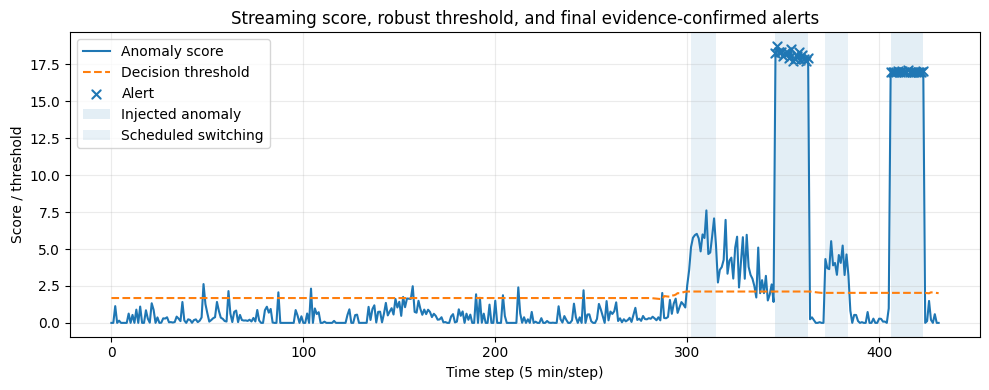

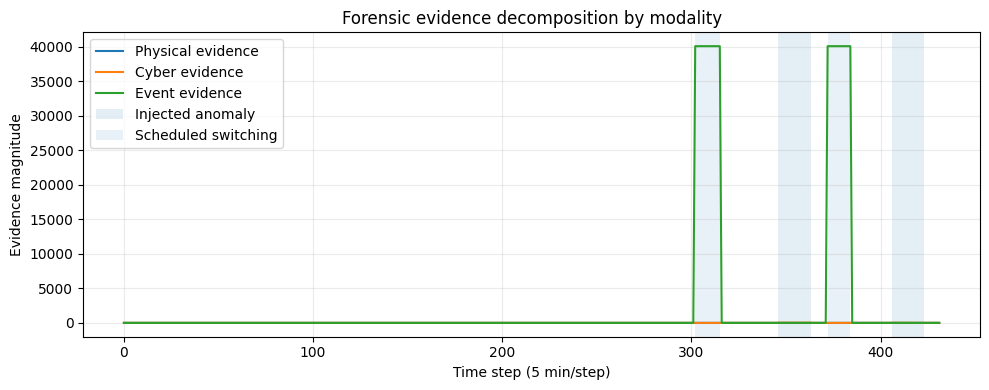

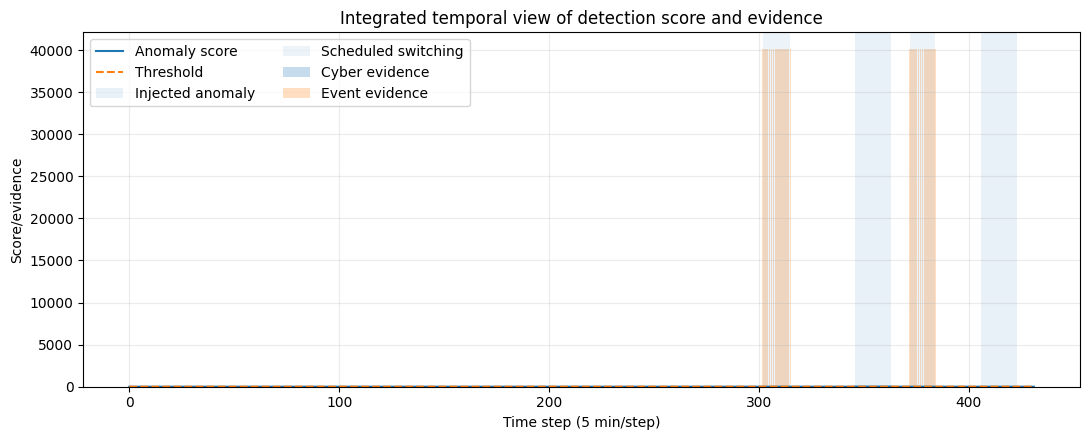

✅ Figures and underlying CSV data saved.


In [ ]:
# ============================================================
# CELL 12 — PAPER-READY FIGURES WITH UNAMBIGUOUS FILENAMES
# Fixes submitted-paper Fig. 2/Fig. 3 caption mismatch risk.
# ============================================================


def shade_windows(ax, windows, label, alpha=0.15):
    used = False
    for a, b in windows:
        ax.axvspan(a, b, alpha=alpha, label=label if not used else None)
        used = True


def save_score_threshold_figure(df: pd.DataFrame, meta: StreamMeta, outdir: str = OUTDIR):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df["t"], df["score"], label="Anomaly score")
    ax.plot(df["t"], df["threshold"], linestyle="--", label="Decision threshold")
    alert_df = df[df["alert"] == 1]
    if len(alert_df):
        ax.scatter(alert_df["t"], alert_df["score"], marker="x", label="Alert")
    shade_windows(ax, meta.anomaly_windows, "Injected anomaly", alpha=0.12)
    shade_windows(ax, meta.switch_windows, "Scheduled switching", alpha=0.10)
    ax.set_xlabel(f"Time step ({meta.timestep_minutes} min/step)")
    ax.set_ylabel("Score / threshold")
    ax.set_title("Streaming score, robust threshold, and final evidence-confirmed alerts")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    png = f"{outdir}/fig_score_threshold_context_aware.png"
    pdf = f"{outdir}/fig_score_threshold_context_aware.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.show()
    return png, pdf


def save_modality_figure(df: pd.DataFrame, meta: StreamMeta, outdir: str = OUTDIR):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df["t"], df["err_phys"], label="Physical evidence")
    ax.plot(df["t"], df["err_cyber"], label="Cyber evidence")
    ax.plot(df["t"], df["err_event"], label="Event evidence")
    shade_windows(ax, meta.anomaly_windows, "Injected anomaly", alpha=0.12)
    shade_windows(ax, meta.switch_windows, "Scheduled switching", alpha=0.10)
    ax.set_xlabel(f"Time step ({meta.timestep_minutes} min/step)")
    ax.set_ylabel("Evidence magnitude")
    ax.set_title("Forensic evidence decomposition by modality")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    png = f"{outdir}/fig_modality_decomposition.png"
    pdf = f"{outdir}/fig_modality_decomposition.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.show()
    return png, pdf


def save_integrated_figure(df: pd.DataFrame, meta: StreamMeta, outdir: str = OUTDIR):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(df["t"], df["score"], label="Anomaly score")
    ax.plot(df["t"], df["threshold"], linestyle="--", label="Threshold")
    ax.bar(df["t"], df["err_cyber"], alpha=0.25, label="Cyber evidence")
    ax.bar(df["t"], df["err_event"], alpha=0.25, label="Event evidence")
    shade_windows(ax, meta.anomaly_windows, "Injected anomaly", alpha=0.10)
    shade_windows(ax, meta.switch_windows, "Scheduled switching", alpha=0.08)
    ax.set_xlabel(f"Time step ({meta.timestep_minutes} min/step)")
    ax.set_ylabel("Score/evidence")
    ax.set_title("Integrated temporal view of detection score and evidence")
    ax.legend(loc="best", ncol=2)
    ax.grid(True, alpha=0.25)
    fig.tight_layout()
    png = f"{outdir}/fig_integrated_score_evidence.png"
    pdf = f"{outdir}/fig_integrated_score_evidence.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    plt.show()
    return png, pdf

fig1 = save_score_threshold_figure(df_full, meta)
fig2 = save_modality_figure(df_full, meta)
fig3 = save_integrated_figure(df_full, meta)

fig_data_cols = ["t", "score", "threshold", "alert", "y_true", "switching", "err_phys", "err_cyber", "err_event", "attack_type"]
df_full[fig_data_cols].to_csv(f"{OUTDIR}/figure_score_evidence_data.csv", index=False)
print("✅ Figures and underlying CSV data saved.")

In [ ]:
# ============================================================
# CELL 13 — FORENSIC BUNDLE SUMMARY TABLE AND EXPORTS
# ============================================================



def summarize_segments(df: pd.DataFrame, meta: StreamMeta):
    """Create non-overlapping segment summaries for the response manuscript."""
    windows = [
        ("Nominal training", 0, max(0, meta.train_end - 1)),
        ("Nominal validation", meta.train_end, max(meta.train_end, meta.val_end - 1)),
    ]

    labelled = []
    for i, (a, b) in enumerate(meta.switch_windows, 1):
        labelled.append((a, b, f"Switch window {i}", "Scheduled topology change/context"))
    for i, (a, b) in enumerate(meta.anomaly_windows, 1):
        labelled.append((a, b, f"Injected anomaly {i}", "Injected anomaly interval"))
    labelled = sorted(labelled, key=lambda x: x[0])

    prev_end = meta.val_end - 1
    gap_id = 1
    for a, b, label, interp in labelled:
        if a > prev_end + 1:
            windows.append((f"Nominal/recovery gap {gap_id}", prev_end + 1, a - 1))
            gap_id += 1
        windows.append((label, a, b))
        prev_end = max(prev_end, b)
    if prev_end < meta.T - 1:
        windows.append(("Final recovery", prev_end + 1, meta.T - 1))

    rows = []
    for label, a, b in windows:
        if a > b:
            continue
        d = df[(df["t"] >= a) & (df["t"] <= b)].copy()
        if len(d) == 0:
            continue
        d["dominant_modality"] = d.apply(dominant_modality, axis=1)
        top_nodes = []
        for nodes in d["top_nodes"].tolist():
            top_nodes.extend(nodes[:3])
        common_nodes = pd.Series(top_nodes).value_counts().head(6).index.astype(int).tolist() if top_nodes else []
        interpretation = (
            "Scheduled topology change/context" if "Switch" in label else
            "Injected anomaly interval" if "anomaly" in label else
            "Nominal/recovery operation"
        )
        rows.append({
            "Segment": label,
            "t_range": f"{a}-{b}",
            "Alert_%": 100.0 * d["alert"].mean(),
            "RawAlert_%": 100.0 * d.get("raw_alert", d["alert"]).mean(),
            "StrongCyber_%": 100.0 * d.get("strong_cyber", pd.Series(np.zeros(len(d)), index=d.index)).mean(),
            "StrongPhysical_%": 100.0 * d.get("strong_physical", pd.Series(np.zeros(len(d)), index=d.index)).mean(),
            "PhysicalConfirmed_%": 100.0 * d.get("physical_confirmed", pd.Series(np.zeros(len(d)), index=d.index)).mean(),
            "MeanScore": d["score"].mean(),
            "MeanThreshold": d["threshold"].mean(),
            "DominantModality": d["dominant_modality"].mode().iloc[0] if len(d["dominant_modality"].mode()) else "n/a",
            "SwitchContext": "Yes" if d["switching"].max() == 1 else "No",
            "TopLocalizedNodes": str(common_nodes),
            "Interpretation": interpretation,
        })
    return pd.DataFrame(rows)

bundle_table = summarize_segments(df_full, meta)
display(bundle_table)
bundle_table.to_csv(f"{OUTDIR}/table_forensic_bundle_summary.csv", index=False)

snapshot_rows = df_full.head(25).copy()
snapshot_cols = ["t", "score", "threshold", "err_phys", "err_cyber", "err_event", "phys_z", "cyber_z", "rec_z", "strong_cyber", "strong_physical", "cyber_confirmed", "physical_confirmed_raw", "physical_confirmed_persistent", "physical_block_context", "alert", "switching", "switch_event"]
snapshot_cols = [c for c in snapshot_cols if c in snapshot_rows.columns]
snapshot_table = snapshot_rows[snapshot_cols].round(4)
display(snapshot_table)
snapshot_table.to_csv(f"{OUTDIR}/table_evidence_snapshot_with_theta.csv", index=False)

baseline_table.to_latex(f"{OUTDIR}/table_baseline_comparison.tex", index=False, float_format="%.3f")
threshold_table.to_latex(f"{OUTDIR}/table_threshold_calibration.tex", index=False, float_format="%.3f")
if "decision_table" in globals():
    decision_table.to_latex(f"{OUTDIR}/table_decision_rule_ablation.tex", index=False, float_format="%.3f")
if "phys_branch_table" in globals():
    phys_branch_table.to_latex(f"{OUTDIR}/table_physical_branch_sensitivity.tex", index=False, float_format="%.3f")
df_loc.to_latex(f"{OUTDIR}/table_localization_topk_full.tex", index=False, float_format="%.3f")
runtime_table.to_latex(f"{OUTDIR}/table_runtime_efficiency.tex", index=False, float_format="%.3f")
bundle_table.to_latex(f"{OUTDIR}/table_forensic_bundle_summary.tex", index=False, float_format="%.3f")
snapshot_table.to_latex(f"{OUTDIR}/table_evidence_snapshot_with_theta.tex", index=False, float_format="%.3f")

config = {
    "notebook_title": NOTEBOOK_TITLE,
    "output_location": {
        "notebook_dir": str(NOTEBOOK_DIR),
        "outdir": str(OUTDIR),
        "zip_path": str(OUTDIR) + ".zip",
    },
    "main_config": {
        "case": CASE,
        "T": T,
        "timestep_minutes": TIMESTEP_MINUTES,
        "window_W": W,
        "seed": SEED,
        "train_end_frac": TRAIN_END_FRAC,
        "val_end_frac": VAL_END_FRAC,
    },
    "model_config": {
        "hidden": HIDDEN,
        "mask_ratio": MASK_RATIO,
        "lambda_temp": LAMBDA_TEMP,
        "lambda_var": LAMBDA_VAR,
        "lambda_edge": LAMBDA_EDGE,
        "lambda_phys": LAMBDA_PHYS,
        "alpha": ALPHA,
        "beta": BETA,
        "score_mode": SCORE_MODE,
        "rec_weight": REC_WEIGHT,
        "cyber_weight": CYBER_WEIGHT,
        "phys_weight": PHYS_WEIGHT,
        "edge_weight": EDGE_WEIGHT,
        "lat_weight": LAT_WEIGHT,
        "threshold_method": DEFAULT_THRESHOLD_METHOD,
        "context_aware_alerting": CONTEXT_AWARE_ALERTING,
        "cyber_confirm_z": CYBER_CONFIRM_Z,
        "phys_confirm_z": PHYS_CONFIRM_Z,
        "phys_min_rec_z": PHYS_MIN_REC_Z,
        "phys_confirm_persistence_k": PHYS_CONFIRM_PERSISTENCE_K,
        "phys_require_high_score": PHYS_REQUIRE_HIGH_SCORE,
        "enable_physical_confirmation": ENABLE_PHYSICAL_CONFIRMATION,
        "persistence_k": PERSISTENCE_K,
        "switch_grace_steps": SWITCH_GRACE_STEPS,
        "pre_switch_grace_steps": PRE_SWITCH_GRACE_STEPS,
        "post_switch_grace_steps": POST_SWITCH_GRACE_STEPS,
        "phys_pre_switch_block_steps": PHYS_PRE_SWITCH_BLOCK_STEPS,
        "phys_post_switch_block_steps": PHYS_POST_SWITCH_BLOCK_STEPS,
        "switch_suppress_alerts": SWITCH_SUPPRESS_ALERTS,
        "switch_override_factor": SWITCH_OVERRIDE_FACTOR,
    },
    "stream_meta": asdict(meta),
    "stress_test_config": {
        "run_reviewer_stress_tests": RUN_REVIEWER_STRESS_TESTS,
        "stress_test_seeds": STRESS_TEST_SEEDS,
        "attack_severities": ATTACK_SEVERITIES,
        "stress_test_epochs": STRESS_TEST_EPOCHS,
        "run_attack_severity_sweep": RUN_ATTACK_SEVERITY_SWEEP,
        "run_physical_only_attack_test": RUN_PHYSICAL_ONLY_ATTACK_TEST,
        "run_attack_during_switch_test": RUN_ATTACK_DURING_SWITCH_TEST,
        "run_case118_runtime": RUN_CASE118_RUNTIME,
    },
    "generalization_config": {
        "run_multi_case_generalization": RUN_MULTI_CASE_GENERALIZATION,
        "generalization_cases": GENERALIZATION_CASES,
        "generalization_seeds": GENERALIZATION_SEEDS,
        "generalization_epochs": GENERALIZATION_EPOCHS,
        "run_transfer_generalization": RUN_TRANSFER_GENERALIZATION,
        "transfer_source_cases": TRANSFER_SOURCE_CASES,
        "transfer_target_cases": TRANSFER_TARGET_CASES,
        "transfer_seeds": TRANSFER_SEEDS,
    },
    "reviewer_response_notes": [
        "Temporal consistency collapse addressed through masked reconstruction, variance diagnostics, and ablation table.",
        "Edge features participate in message passing and auxiliary edge reconstruction.",
        "Physical consistency term is lightweight and not claimed as full AC power-flow enforcement.",
        "Threshold updates can be frozen during alerts and scheduled switching to avoid threshold drift.",
        "Context-aware cyber confirmation suppresses switch/event-only reconstruction spikes in the final alert decision.",
        "A separate persistent physical-evidence branch is included for physical-only stress tests outside switching context.",
        "Runtime table reports measured ms/step and throughput for the benchmark graph.",
        "If cross-topology results are weak, remove foundation model from title and claims.",
    ],
}
with open(f"{OUTDIR}/experiment_config.json", "w") as f:
    json.dump(config, f, indent=2)

print(f"✅ All reviewer-response artifacts saved in: {OUTDIR}/")

,Segment,t_range,Alert_%,RawAlert_%,StrongCyber_%,StrongPhysical_%,PhysicalConfirmed_%,MeanScore,MeanThreshold,DominantModality,SwitchContext,TopLocalizedNodes,Interpretation
0,Nominal training,0-215,0.0,0.000000,0.0,0.000000,0.0,0.447860,1.681699,cyber,No,"[19, 30, 11, 29, 38, 34]",Nominal/recovery operation
1,Nominal validation,216-280,0.0,0.000000,0.0,0.000000,0.0,0.343208,1.681699,cyber,No,"[19, 11, 30, 8, 38, 16]",Nominal/recovery operation
2,Nominal/recovery gap 1,281-301,0.0,14.285714,0.0,0.000000,0.0,1.021351,1.845639,physical,Yes,"[19, 30, 11, 8, 24, 31]",Nominal/recovery operation
3,Switch window 1,302-315,0.0,100.000000,0.0,71.428571,0.0,5.740714,2.121669,event,Yes,"[30, 19, 11, 31, 18]",Scheduled topology change/context
4,Nominal/recovery gap 2,316-345,0.0,80.000000,0.0,60.000000,0.0,3.513570,2.121669,physical,Yes,"[30, 19, 29, 11, 31, 6]",Nominal/recovery operation
5,Injected anomaly 1,346-363,100.0,100.000000,100.0,11.111111,0.0,18.117163,2.121669,cyber,Yes,"[24, 37, 32, 30, 33, 21]",Injected anomaly interval
6,Nominal/recovery gap 3,364-371,0.0,0.000000,0.0,0.000000,0.0,0.106371,2.068348,cyber,Yes,"[19, 30, 11, 29, 34, 37]",Nominal/recovery operation
7,Switch window 2,372-384,0.0,100.000000,0.0,0.000000,0.0,4.104156,2.031237,event,Yes,"[19, 30, 37, 31, 11]",Scheduled topology change/context
8,Nominal/recovery gap 4,385-405,0.0,0.000000,0.0,0.000000,0.0,0.229225,2.031237,cyber,Yes,"[19, 11, 30, 29, 34, 37]",Nominal/recovery operation
9,Injected anomaly 2,406-423,100.0,100.000000,100.0,0.000000,0.0,17.013504,2.031237,cyber,Yes,"[24, 32, 33, 37, 21, 30]",Injected anomaly interval


,t,score,threshold,err_phys,err_cyber,err_event,phys_z,cyber_z,rec_z,strong_cyber,strong_physical,cyber_confirmed,physical_confirmed_raw,physical_confirmed_persistent,physical_block_context,alert,switching,switch_event
0,0,0.0000,1.6817,0.4060,0.8638,0.0020,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0
1,1,0.0000,1.6817,0.5219,0.6777,0.0014,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0
2,2,1.1343,1.6817,0.4012,1.1133,0.0015,0.0000,1.6205,0.0000,0,0,0,0,0,0,0,0,0
3,3,0.0000,1.6817,0.4909,0.8828,0.0018,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0
4,4,0.1517,1.6817,0.5346,0.9273,0.0022,0.0000,0.2167,0.0000,0,0,0,0,0,0,0,0,0
5,5,0.0000,1.6817,0.5265,0.8474,0.0018,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0
6,6,0.0000,1.6817,0.5312,0.5831,0.0017,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0
7,7,0.0000,1.6817,0.4651,0.7558,0.0021,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0
8,8,0.0000,1.6817,0.4521,0.7296,0.0025,0.0000,0.0000,0.0000,0,0,0,0,0,0,0,0,0
9,9,0.6303,1.6817,0.4668,1.0179,0.0020,0.0000,0.9004,0.0000,0,0,0,0,0,0,0,0,0


✅ All reviewer-response artifacts saved in: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/


In [ ]:
# ============================================================
# CELL 14 — ZIP ALL OUTPUTS AND FORCE A DRIVE COPY
# ============================================================

import os
import shutil
import zipfile
from pathlib import Path

# Ensure all filesystem buffers are flushed before zipping/copying.
os.sync()

# Create the zip directly in the Google Drive notebook folder.
drive_zip_path = NOTEBOOK_DIR / f"{NOTEBOOK_STEM}_outputs.zip"
if drive_zip_path.exists():
    drive_zip_path.unlink()

with zipfile.ZipFile(drive_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in OUTDIR.rglob("*"):
        if file_path.is_file():
            zf.write(file_path, arcname=file_path.relative_to(OUTDIR))

# Also create/update a /content backup copy for immediate Colab download.
if LOCAL_BACKUP_DIR.exists():
    shutil.rmtree(LOCAL_BACKUP_DIR)
shutil.copytree(OUTDIR, LOCAL_BACKUP_DIR)
if LOCAL_BACKUP_ZIP.exists():
    LOCAL_BACKUP_ZIP.unlink()
shutil.copy2(drive_zip_path, LOCAL_BACKUP_ZIP)

# Write a small marker file in Drive so the user can quickly verify sync/visibility.
marker = NOTEBOOK_DIR / f"{NOTEBOOK_STEM}_OUTPUTS_CREATED.txt"
marker.write_text(
    f"Outputs created for {NOTEBOOK_STEM}\n"
    f"Output folder: {OUTDIR}\n"
    f"Drive zip: {drive_zip_path}\n"
    f"Local backup zip: {LOCAL_BACKUP_ZIP}\n"
)
os.sync()

print("✅ Created Google Drive output folder:", OUTDIR)
print("✅ Created Google Drive zip:", drive_zip_path)
print("✅ Created local backup zip:", LOCAL_BACKUP_ZIP)
print("✅ Drive marker file:", marker)
print("\nWindows Google Drive path should correspond approximately to:")
print(r"G:\My Drive\W26\smart Grid\smartGridV04\experiments" + f"\\{NOTEBOOK_STEM}_outputs.zip")

try:
    print("Drive zip size (MB):", round(drive_zip_path.stat().st_size / (1024 * 1024), 3))
except Exception as e:
    print("Could not stat Drive zip:", e)


✅ Created Google Drive output folder: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs
✅ Created Google Drive zip: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs.zip
✅ Created local backup zip: /content/Grid007_reviewer_context_aware_v9_outputs.zip
✅ Drive marker file: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_OUTPUTS_CREATED.txt

Windows Google Drive path should correspond approximately to:
G:\My Drive\W26\smart Grid\smartGridV04\experiments\Grid007_reviewer_context_aware_v9_outputs.zip
Drive zip size (MB): 0.572


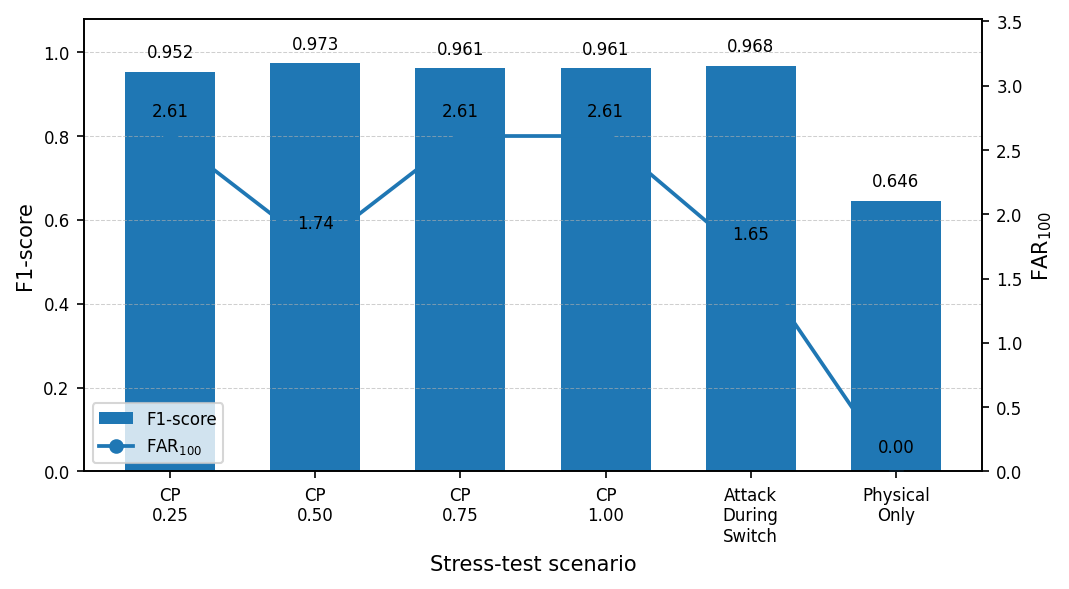

Saved PNG: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/paper_figures/fig_stress_test_robustness.png
Saved PDF: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/paper_figures/fig_stress_test_robustness.pdf
Also saved to: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/fig_stress_test_robustness.png
Also saved to: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/fig_stress_test_robustness.pdf


In [ ]:
# ============================================================
# Stress-test robustness figure for paper
# Saves:
# 1) /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/paper_figures/
# 2) /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path("/content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments")
OUTDIR = BASE_DIR / "Grid007_reviewer_context_aware_v9_outputs"
FIGDIR = OUTDIR / "paper_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Stress-test summary values from v9 results
# ------------------------------------------------------------
df = pd.DataFrame({
    "Scenario": [
        "CP\n0.25",
        "CP\n0.50",
        "CP\n0.75",
        "CP\n1.00",
        "Attack\nDuring\nSwitch",
        "Physical\nOnly"
    ],
    "Precision": [0.925, 0.949, 0.927, 0.927, 0.939, 1.000],
    "Recall":    [0.981, 1.000, 1.000, 1.000, 1.000, 0.478],
    "F1":        [0.952, 0.973, 0.961, 0.961, 0.968, 0.646],
    "FAR100":    [2.609, 1.739, 2.609, 2.609, 1.653, 0.000],
    "EventRecall": [1.000, 1.000, 1.000, 1.000, 1.000, 0.500],
})

# Save the plotted data for reproducibility
df.to_csv(FIGDIR / "fig_stress_test_robustness_data.csv", index=False)

# ------------------------------------------------------------
# Figure style
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 600,
})

x = np.arange(len(df))

fig, ax1 = plt.subplots(figsize=(7.2, 4.0))

# Bar: F1-score
bars = ax1.bar(x, df["F1"], width=0.62, label="F1-score")
ax1.set_ylabel("F1-score")
ax1.set_ylim(0, 1.08)
ax1.set_xticks(x)
ax1.set_xticklabels(df["Scenario"])
ax1.set_xlabel("Stress-test scenario")
ax1.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# Label bars
for i, value in enumerate(df["F1"]):
    ax1.text(i, value + 0.025, f"{value:.3f}", ha="center", va="bottom", fontsize=8)

# Line: FAR100
ax2 = ax1.twinx()
line_far, = ax2.plot(
    x,
    df["FAR100"],
    marker="o",
    linewidth=1.8,
    label=r"FAR$_{100}$"
)
ax2.set_ylabel(r"FAR$_{100}$")
ax2.set_ylim(0, max(df["FAR100"].max() * 1.35, 3.0))

# Label FAR100 values
for i, value in enumerate(df["FAR100"]):
    ax2.text(i, value + 0.12, f"{value:.2f}", ha="center", va="bottom", fontsize=8)

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="lower left", frameon=True)

# No title inside the figure; the paper caption will describe it.
fig.tight_layout()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
png_path = FIGDIR / "fig_stress_test_robustness.png"
pdf_path = FIGDIR / "fig_stress_test_robustness.pdf"

fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

# Also save/copy directly in experiment folder for LaTeX convenience
fig.savefig(BASE_DIR / "fig_stress_test_robustness.png", bbox_inches="tight")
fig.savefig(BASE_DIR / "fig_stress_test_robustness.pdf", bbox_inches="tight")

plt.show()

print("Saved PNG:", png_path)
print("Saved PDF:", pdf_path)
print("Also saved to:", BASE_DIR / "fig_stress_test_robustness.png")
print("Also saved to:", BASE_DIR / "fig_stress_test_robustness.pdf")

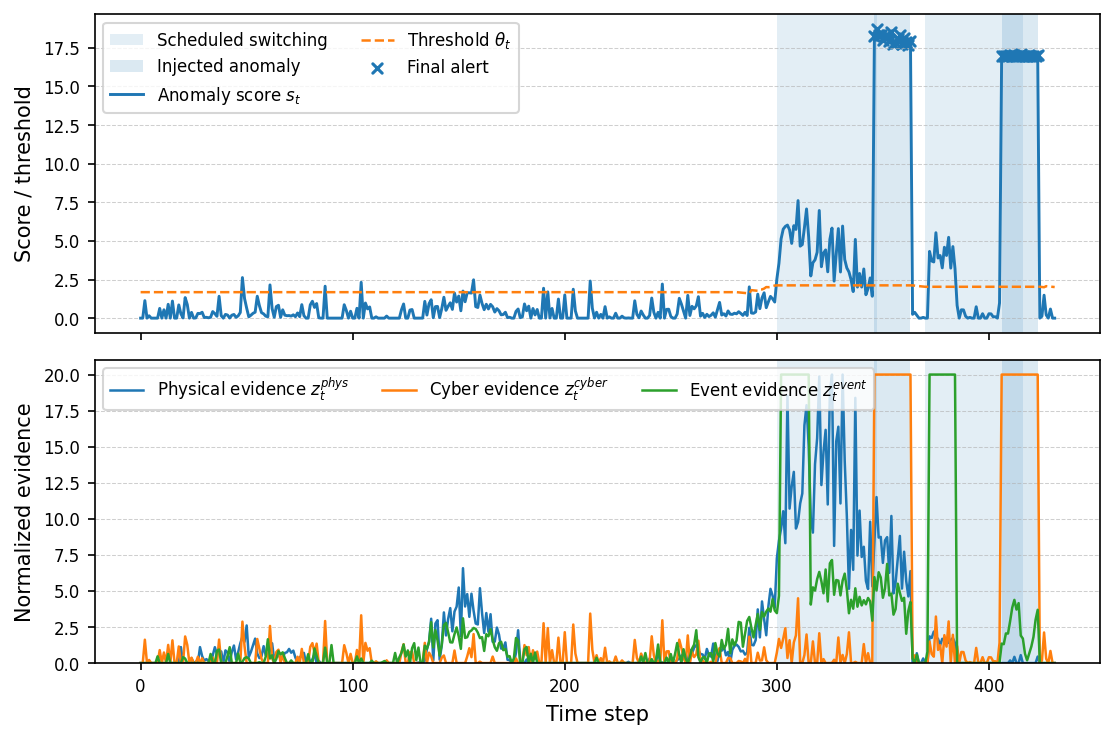

Saved PNG: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/paper_figures/fig_integrated_score_evidence_v9.png
Saved PDF: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/paper_figures/fig_integrated_score_evidence_v9.pdf
Also saved to: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/fig_integrated_score_evidence_v9.png
Also saved to: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/fig_integrated_score_evidence_v9.pdf


In [ ]:
# ============================================================
# New v9 integrated temporal figure
# Replaces old Figure 5 based on old 180-step result
# Saves PNG and PDF to:
# 1) v9 output paper_figures folder
# 2) experiments folder for direct LaTeX use
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path("/content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments")
OUTDIR = BASE_DIR / "Grid007_reviewer_context_aware_v9_outputs"
FIGDIR = OUTDIR / "paper_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = OUTDIR / "evidence_stream_full_proposed.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing file: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

# ------------------------------------------------------------
# Helper: contiguous spans for shading
# ------------------------------------------------------------
def contiguous_spans(mask, t_values):
    mask = np.asarray(mask).astype(bool)
    t_values = np.asarray(t_values)
    spans = []
    start = None

    for i, flag in enumerate(mask):
        if flag and start is None:
            start = t_values[i]
        if start is not None and (not flag or i == len(mask) - 1):
            end = t_values[i - 1] if not flag else t_values[i]
            spans.append((start, end))
            start = None
    return spans

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
t = df["t"].values

# Main score/threshold/alerts
score = df["score"].values
threshold = df["threshold"].values
alerts = df["alert"].astype(int).values
raw_alerts = df["raw_alert"].astype(int).values if "raw_alert" in df.columns else (score > threshold).astype(int)

# Evidence z-scores if available
phys_z = df["phys_z"].values if "phys_z" in df.columns else df["err_phys"].values
cyber_z = df["cyber_z"].values if "cyber_z" in df.columns else df["err_cyber"].values

# Event evidence can be very large, so normalize robustly for visual comparison
event_raw = df["err_event"].values
nominal_mask = (df["y_true"].values == 0) & (df["switching"].values == 0)
event_med = np.median(event_raw[nominal_mask])
event_mad = np.median(np.abs(event_raw[nominal_mask] - event_med)) + 1e-9
event_z = (event_raw - event_med) / (1.4826 * event_mad + 1e-9)

# Clip evidence only for display
phys_plot = np.clip(phys_z, 0, 20)
cyber_plot = np.clip(cyber_z, 0, 20)
event_plot = np.clip(event_z, 0, 20)

# Spans
anomaly_spans = contiguous_spans(df["y_true"].values == 1, t)
switch_spans = contiguous_spans(df["switching"].values == 1, t)

# ------------------------------------------------------------
# Figure style
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 600,
})

# ------------------------------------------------------------
# Create figure: two-panel integrated temporal view
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(7.4, 5.0),
    sharex=True,
    gridspec_kw={"height_ratios": [1.05, 1.0]}
)

# -------------------------
# Top panel: score/threshold/alerts
# -------------------------
for s, e in switch_spans:
    ax1.axvspan(s, e, alpha=0.12, label="Scheduled switching" if s == switch_spans[0][0] else None)

for s, e in anomaly_spans:
    ax1.axvspan(s, e, alpha=0.16, label="Injected anomaly" if s == anomaly_spans[0][0] else None)

ax1.plot(t, score, linewidth=1.4, label=r"Anomaly score $s_t$")
ax1.plot(t, threshold, linestyle="--", linewidth=1.2, label=r"Threshold $\theta_t$")

alert_t = t[alerts == 1]
alert_y = score[alerts == 1]
ax1.scatter(alert_t, alert_y, marker="x", s=20, label="Final alert")

ax1.set_ylabel("Score / threshold")
ax1.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
ax1.legend(loc="upper left", ncol=2, frameon=True)

# -------------------------
# Bottom panel: modality evidence
# -------------------------
for s, e in switch_spans:
    ax2.axvspan(s, e, alpha=0.12)

for s, e in anomaly_spans:
    ax2.axvspan(s, e, alpha=0.16)

ax2.plot(t, phys_plot, linewidth=1.2, label=r"Physical evidence $z_t^{phys}$")
ax2.plot(t, cyber_plot, linewidth=1.2, label=r"Cyber evidence $z_t^{cyber}$")
ax2.plot(t, event_plot, linewidth=1.2, label=r"Event evidence $z_t^{event}$")

ax2.set_xlabel("Time step")
ax2.set_ylabel("Normalized evidence")
ax2.set_ylim(0, 21)
ax2.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
ax2.legend(loc="upper left", ncol=3, frameon=True)

fig.tight_layout()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
png_path = FIGDIR / "fig_integrated_score_evidence_v9.png"
pdf_path = FIGDIR / "fig_integrated_score_evidence_v9.pdf"

fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

# Also save directly in experiment folder for LaTeX convenience
fig.savefig(BASE_DIR / "fig_integrated_score_evidence_v9.png", bbox_inches="tight")
fig.savefig(BASE_DIR / "fig_integrated_score_evidence_v9.pdf", bbox_inches="tight")

plt.show()

print("Saved PNG:", png_path)
print("Saved PDF:", pdf_path)
print("Also saved to:", BASE_DIR / "fig_integrated_score_evidence_v9.png")
print("Also saved to:", BASE_DIR / "fig_integrated_score_evidence_v9.pdf")

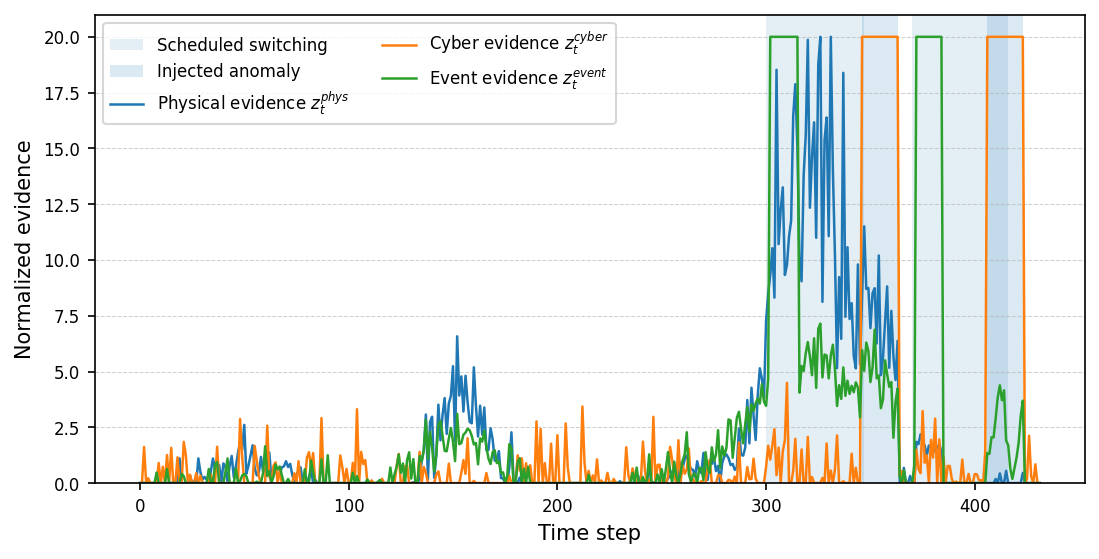

Saved PNG: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/paper_figures/fig_modality_decomposition_v9.png
Saved PDF: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/Grid007_reviewer_context_aware_v9_outputs/paper_figures/fig_modality_decomposition_v9.pdf
Also saved to: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/fig_modality_decomposition_v9.png
Also saved to: /content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments/fig_modality_decomposition_v9.pdf


In [ ]:
# ============================================================
# v9 Modality-wise evidence decomposition figure
# Replaces old Figure 3 and Figure 4 based on old 180-step run
# Saves PNG/PDF in:
# 1) v9 output paper_figures folder
# 2) experiments folder for direct LaTeX use
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path("/content/drive/MyDrive/W26/smart Grid/smartGridV04/experiments")
OUTDIR = BASE_DIR / "Grid007_reviewer_context_aware_v9_outputs"
FIGDIR = OUTDIR / "paper_figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = OUTDIR / "evidence_stream_full_proposed.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing file: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

# ------------------------------------------------------------
# Helper for shaded regions
# ------------------------------------------------------------
def contiguous_spans(mask, t_values):
    mask = np.asarray(mask).astype(bool)
    t_values = np.asarray(t_values)
    spans = []
    start = None

    for i, flag in enumerate(mask):
        if flag and start is None:
            start = t_values[i]
        if start is not None and (not flag or i == len(mask) - 1):
            end = t_values[i - 1] if not flag else t_values[i]
            spans.append((start, end))
            start = None
    return spans

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
t = df["t"].values

# Use z-score evidence if available; otherwise robustly normalize raw evidence.
if "phys_z" in df.columns:
    phys = df["phys_z"].values
else:
    phys = df["err_phys"].values

if "cyber_z" in df.columns:
    cyber = df["cyber_z"].values
else:
    cyber = df["err_cyber"].values

# Event evidence can be very large, so robustly normalize it for display
event_raw = df["err_event"].values
nominal_mask = (df["y_true"].values == 0) & (df["switching"].values == 0)

event_med = np.median(event_raw[nominal_mask])
event_mad = np.median(np.abs(event_raw[nominal_mask] - event_med)) + 1e-9
event = (event_raw - event_med) / (1.4826 * event_mad + 1e-9)

# Clip for paper readability
phys_plot = np.clip(phys, 0, 20)
cyber_plot = np.clip(cyber, 0, 20)
event_plot = np.clip(event, 0, 20)

anomaly_spans = contiguous_spans(df["y_true"].values == 1, t)
switch_spans = contiguous_spans(df["switching"].values == 1, t)

# ------------------------------------------------------------
# Figure style
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 600,
})

fig, ax = plt.subplots(figsize=(7.4, 3.8))

# Shaded regions
for idx, (s, e) in enumerate(switch_spans):
    ax.axvspan(s, e, alpha=0.12, label="Scheduled switching" if idx == 0 else None)

for idx, (s, e) in enumerate(anomaly_spans):
    ax.axvspan(s, e, alpha=0.16, label="Injected anomaly" if idx == 0 else None)

# Evidence lines
ax.plot(t, phys_plot, linewidth=1.2, label=r"Physical evidence $z_t^{phys}$")
ax.plot(t, cyber_plot, linewidth=1.2, label=r"Cyber evidence $z_t^{cyber}$")
ax.plot(t, event_plot, linewidth=1.2, label=r"Event evidence $z_t^{event}$")

ax.set_xlabel("Time step")
ax.set_ylabel("Normalized evidence")
ax.set_ylim(0, 21)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(loc="upper left", ncol=2, frameon=True)

fig.tight_layout()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
png_path = FIGDIR / "fig_modality_decomposition_v9.png"
pdf_path = FIGDIR / "fig_modality_decomposition_v9.pdf"

fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")

# Also save directly in experiment folder for LaTeX
fig.savefig(BASE_DIR / "fig_modality_decomposition_v9.png", bbox_inches="tight")
fig.savefig(BASE_DIR / "fig_modality_decomposition_v9.pdf", bbox_inches="tight")

plt.show()

print("Saved PNG:", png_path)
print("Saved PDF:", pdf_path)
print("Also saved to:", BASE_DIR / "fig_modality_decomposition_v9.png")
print("Also saved to:", BASE_DIR / "fig_modality_decomposition_v9.pdf")

In [2]:
import time
import os
import numpy as np
import torch
import pandas as pd

# Optional CPU memory tracking
try:
    import psutil
    process = psutil.Process(os.getpid())
except Exception:
    psutil = None
    process = None


# ============================================================
# User override section
# ============================================================
# When automatic detection fails, write your actual variable names here, e.g.
# MODEL_NAME = "best_model"
# SNAPSHOTS_NAME = "test_loader"
MODEL_NAME = None
SNAPSHOTS_NAME = None


# ============================================================
# Helper functions
# ============================================================
def find_model():
    if MODEL_NAME is not None:
        if MODEL_NAME not in globals():
            raise NameError(f"MODEL_NAME='{MODEL_NAME}' not found in notebook globals.")
        obj = globals()[MODEL_NAME]
        if not isinstance(obj, torch.nn.Module):
            raise TypeError(f"MODEL_NAME='{MODEL_NAME}' exists but is not a torch.nn.Module.")
        return obj, MODEL_NAME

    candidates = []
    for name, obj in globals().items():
        if isinstance(obj, torch.nn.Module):
            candidates.append((name, obj))

    if len(candidates) == 0:
        raise NameError(
            "No PyTorch model was found in notebook memory.\n"
            "Load your checkpoint/model first, or set MODEL_NAME to the correct model variable.\n"
            "Example: MODEL_NAME = 'best_model'"
        )

    print("Detected model candidates:")
    for name, obj in candidates:
        print(f"  {name}: {type(obj).__name__}")

    # Prefer common names
    preferred = ["model", "best_model", "net", "encoder", "gnn", "trained_model"]
    for p in preferred:
        for name, obj in candidates:
            if name == p:
                print(f"\nUsing model variable: {name}")
                return obj, name

    name, obj = candidates[0]
    print(f"\nUsing first detected model variable: {name}")
    return obj, name


def find_snapshots():
    if SNAPSHOTS_NAME is not None:
        if SNAPSHOTS_NAME not in globals():
            raise NameError(f"SNAPSHOTS_NAME='{SNAPSHOTS_NAME}' not found in notebook globals.")
        return globals()[SNAPSHOTS_NAME], SNAPSHOTS_NAME

    keywords = ["test", "loader", "dataset", "snap", "graph", "stream"]
    candidates = []

    for name, obj in globals().items():
        lname = name.lower()
        if any(k in lname for k in keywords):
            if hasattr(obj, "__iter__") and not isinstance(obj, (str, bytes, dict)):
                candidates.append((name, obj))

    if len(candidates) == 0:
        raise NameError(
            "No test loader/snapshot collection was found in notebook memory.\n"
            "Set SNAPSHOTS_NAME to your actual test data variable.\n"
            "Example: SNAPSHOTS_NAME = 'test_loader' or SNAPSHOTS_NAME = 'test_snapshots'"
        )

    print("\nDetected test-data candidates:")
    for name, obj in candidates:
        length = len(obj) if hasattr(obj, "__len__") else "unknown"
        print(f"  {name}: {type(obj).__name__}, len={length}")

    preferred = [
        "test_loader",
        "test_snapshots",
        "test_dataset",
        "test_graphs",
        "test_stream",
        "snapshots",
    ]

    for p in preferred:
        for name, obj in candidates:
            if name == p:
                print(f"\nUsing test-data variable: {name}")
                return obj, name

    name, obj = candidates[0]
    print(f"\nUsing first detected test-data variable: {name}")
    return obj, name


def move_to_device(batch, device):
    """Move PyG Data/Batch, tensors, tuples, lists, or dicts to device."""
    if hasattr(batch, "to"):
        return batch.to(device)
    if torch.is_tensor(batch):
        return batch.to(device)
    if isinstance(batch, dict):
        return {k: move_to_device(v, device) for k, v in batch.items()}
    if isinstance(batch, (list, tuple)):
        return type(batch)(move_to_device(v, device) for v in batch)
    return batch


def model_forward(model, batch):
    """
    Generic model call.

    For most PyG models:
        output = model(batch)

    When your model uses separate arguments, replace this function accordingly, e.g.
        output = model(batch.x, batch.edge_index, batch.edge_attr)
    """
    return model(batch)


@torch.no_grad()
def run_one_snapshot(model, snapshot, device):
    snapshot = move_to_device(snapshot, device)

    # Forward pass
    output = model_forward(model, snapshot)

    # Add scoring/evidence calls here only if your functions are already available.
    # Example:
    # score = compute_score(output, snapshot)
    # alert = confirm_alert(score)
    # evidence = build_evidence_bundle(output, snapshot, score, alert)

    return output


# ============================================================
# Runtime profiling
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, model_var_name = find_model()
snapshots, snapshots_var_name = find_snapshots()

model = model.to(device)
model.eval()

print(f"\nProfiling model: {model_var_name}")
print(f"Profiling stream: {snapshots_var_name}")
print(f"Device: {torch.cuda.get_device_name(0) if device.type == 'cuda' else 'CPU'}")

# Warm-up
warmup_count = 20
for i, snapshot in enumerate(snapshots):
    _ = run_one_snapshot(model, snapshot, device)
    if i + 1 >= warmup_count:
        break

if device.type == "cuda":
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()

latencies_ms = []
cpu_memory_mb = []

for snapshot in snapshots:
    if device.type == "cuda":
        torch.cuda.synchronize()

    t0 = time.perf_counter()

    _ = run_one_snapshot(model, snapshot, device)

    if device.type == "cuda":
        torch.cuda.synchronize()

    t1 = time.perf_counter()

    latencies_ms.append((t1 - t0) * 1000.0)

    if process is not None:
        cpu_memory_mb.append(process.memory_info().rss / (1024 ** 2))

latencies_ms = np.array(latencies_ms)

mean_latency = float(latencies_ms.mean())
std_latency = float(latencies_ms.std())
p95_latency = float(np.percentile(latencies_ms, 95))
throughput = float(1000.0 / mean_latency)

if device.type == "cuda":
    peak_memory_mb = float(torch.cuda.max_memory_allocated() / (1024 ** 2))
    device_name = torch.cuda.get_device_name(0)
else:
    peak_memory_mb = float(max(cpu_memory_mb)) if len(cpu_memory_mb) > 0 else np.nan
    device_name = "CPU"

summary = {
    "device": device_name,
    "model_variable": model_var_name,
    "test_data_variable": snapshots_var_name,
    "num_snapshots": len(latencies_ms),
    "mean_latency_ms": mean_latency,
    "std_latency_ms": std_latency,
    "p95_latency_ms": p95_latency,
    "throughput_snapshots_per_s": throughput,
    "peak_memory_mb": peak_memory_mb,
}

df = pd.DataFrame([summary])

print("\nRuntime profile:")
print(df.to_string(index=False))

df.to_csv("runtime_profile_ieee39.csv", index=False)
print("\nSaved: runtime_profile_ieee39.csv")

NameError: No PyTorch model was found in notebook memory.
Load your checkpoint/model first, or set MODEL_NAME to the correct model variable.
Example: MODEL_NAME = 'best_model'